# Predicting Moral Values From Social Media Discourse

In [1]:
import os
import random
import re
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from itertools import product
from scipy.special import softmax
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    multilabel_confusion_matrix as mcm,
    precision_score,
    recall_score
)
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from tabulate import tabulate
from torch.autograd import Function
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler, TensorDataset
from tqdm import trange
from tqdm.auto import trange
from transformers import (
    AutoConfig,
    AutoModel,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    BertModel,
    PretrainedConfig,
    PreTrainedModel,
    get_linear_schedule_with_warmup
)
from transformers.modeling_outputs import SequenceClassifierOutput

## Define Base Model

In [2]:
base_model = "cahya/bert-base-indonesian-1.5G"

### Datasets:
- These are the datasets retreived from different sources. Keep in mind that due to different cleaning, pre-processing, you might have different data sizes.

In [3]:
train_df = pd.read_csv("train_indonesia.csv")
test_df = pd.read_csv("test_indonesia.csv")
train_df.head()
test_df.head()

,storyID,story,sentenceID,sentence,kepedulian,menyakiti,keadilan,kecurangan,loyalitas,pengkhianatan,otoritas,pembangkangan,kesucian,kemerosotan,kebebasan,penindasan
0,1,Legenda Danau Toba,2,Ia seorang petani yang rajin bekerja walaupun ...,0,0,0,0,0,0,0,0,0,0,0,0
1,1,Legenda Danau Toba,3,Ia bisa mencukupi kebutuhannya dari hasil kerj...,0,0,0,0,0,0,0,0,0,0,0,0
2,1,Legenda Danau Toba,14,Aku akan bersediamenemanimu jika kau tidak jad...,0,0,0,0,0,0,0,0,0,0,0,0
3,1,Legenda Danau Toba,26,"“Dia mungkin bidadari yang turun dari langit,”...",0,0,0,0,0,0,0,0,0,0,0,0
4,1,Legenda Danau Toba,29,"Karena ketekunan dan keuletannya, petani itu h...",0,0,0,0,0,0,0,0,0,0,0,0


In [4]:
train_df.shape

(18598, 16)

In [5]:
train_df

,storyID,story,sentenceID,sentence,kepedulian,menyakiti,keadilan,kecurangan,loyalitas,pengkhianatan,otoritas,pembangkangan,kesucian,kemerosotan,kebebasan,penindasan
0,1,Legenda Danau Toba,1,"Di sebuah desa di wilayah Sumatera, hidup seor...",0,0,0,0,0,0,0,0,0,0,0,0
1,1,Legenda Danau Toba,4,"Sebenarnya usianya sudah cukup untuk menikah, ...",0,0,0,0,0,0,0,0,0,0,0,0
2,1,Legenda Danau Toba,5,"Di suatu pagi hari yang cerah, petani itu mema...",0,0,0,0,0,0,0,0,0,0,0,0
3,1,Legenda Danau Toba,6,“Mudah-mudahan hari ini aku mendapat ikan yang...,0,0,0,0,0,0,0,0,0,0,0,0
4,1,Legenda Danau Toba,7,"Beberapa saat setelah kailnya dilemparkan, kai...",0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18593,225,Sidang Belawan,151,"“Terima kasih, wahai para bidadari.",0,0,0,0,0,0,0,0,0,0,0,0
18594,225,Sidang Belawan,152,"Aku berjanji akan merawat istriku dengan baik,...",1,0,0,0,0,0,0,0,0,0,0,0
18595,225,Sidang Belawan,153,"Pada akhirnya, Sidang Belawan sukses memboyong...",0,0,0,0,0,0,0,0,0,0,0,0
18596,225,Sidang Belawan,154,Kedatangan mereka disambut dengan penuh kebaha...,0,0,0,0,0,0,0,0,0,0,0,0


In [6]:
train_df[["kepedulian", "menyakiti",
    "keadilan", "kecurangan",
    "loyalitas", "pengkhianatan",
    "otoritas", "pembangkangan",
    "kesucian", "kemerosotan",
    "kebebasan", "penindasan"]].sum()

,0
kepedulian,370
menyakiti,349
keadilan,294
kecurangan,68
loyalitas,107
pengkhianatan,156
otoritas,575
pembangkangan,80
kesucian,434
kemerosotan,82


In [7]:
neutral_text = train_df[(train_df['kepedulian']==0) & (train_df['menyakiti']==0)
   & (train_df['keadilan']==0) & (train_df['kecurangan']==0)
   & (train_df['loyalitas']==0)  & (train_df['pengkhianatan']==0)
   & (train_df['otoritas']==0)& (train_df['pembangkangan']==0)
   & (train_df['kesucian']==0) & (train_df['kemerosotan']==0)
   & (train_df['kebebasan']==0) & (train_df['penindasan']==0)]

print("Neutral (Non-Moral) text: ", len(neutral_text))

Neutral (Non-Moral) text:  16188


In [8]:
len(neutral_text)/len(train_df)

0.8704161737821271

#### Text and label values:

In [9]:
possible_labels = [
    "kepedulian", "menyakiti",
    "keadilan", "kecurangan",
    "loyalitas", "pengkhianatan",
    "otoritas", "pembangkangan",
    "kesucian", "kemerosotan",
    "kebebasan", "penindasan"
]

train_text = train_df["sentence"].values
train_labels = train_df[possible_labels].values

test_text = test_df["sentence"].values
test_labels = test_df[possible_labels].values

In [10]:
def encode_texts(input_texts, tokenizer, max_length=150):
    input_ids = []
    attention_masks = []
    token_type_ids = []

    for sample in input_texts:
        encoding = tokenizer(
            sample,
            add_special_tokens=True,
            max_length=max_length,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_token_type_ids=True,
            return_tensors="pt"
        )

        input_ids.append(encoding["input_ids"])
        attention_masks.append(encoding["attention_mask"])

        if "token_type_ids" in encoding:
            token_type_ids.append(encoding["token_type_ids"])
        else:
            token_type_ids.append(torch.zeros_like(encoding["input_ids"]))

    input_ids = torch.cat(input_ids, dim=0)
    attention_masks = torch.cat(attention_masks, dim=0)
    token_type_ids = torch.cat(token_type_ids, dim=0)

    return input_ids, attention_masks, token_type_ids

In [11]:
base_model = "cahya/bert-base-indonesian-1.5G"
tokenizer = AutoTokenizer.from_pretrained(base_model)

train_input_ids, train_attention_masks, train_token_type_ids = encode_texts(
    train_text, tokenizer, max_length=150
)

test_input_ids, test_attention_masks, test_token_type_ids = encode_texts(
    test_text, tokenizer, max_length=150
)

train_labels_tensor = torch.tensor(train_labels, dtype=torch.float)
test_labels_tensor = torch.tensor(test_labels, dtype=torch.float)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/468 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/62.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

#### Encode corups for original embeddings

In [12]:
def encode_corpus(inputs, attentions, model, batch_size=16):

    all_embeddings = []

    model.eval()

    for start_index in range(0, len(inputs), batch_size):

        b_input_ids = inputs[start_index:start_index+batch_size].to(model.device)
        b_input_mask = attentions[start_index:start_index+batch_size].to(model.device)

        with torch.no_grad():

            outputs = model(
                input_ids=b_input_ids,
                attention_mask=b_input_mask
            )

            cls_embedding = outputs.last_hidden_state[:,0,:].cpu()

        all_embeddings.extend(cls_embedding)

    return torch.stack(all_embeddings)

### Doman Adversarial Function:

In [13]:
import os
import __main__

dummy_py_path = os.path.join(os.getcwd(), "notebook_session.py")
if not os.path.exists(dummy_py_path):
    with open(dummy_py_path, "w", encoding="utf-8") as f:
        f.write("# dummy file for transformers custom model in notebook\n")

__main__.__file__ = dummy_py_path

In [14]:
from transformers import PretrainedConfig, PreTrainedModel, AutoModel, AutoConfig
from transformers.modeling_outputs import SequenceClassifierOutput
import torch
import torch.nn as nn

class PlainBERTConfig(PretrainedConfig):
    model_type = "plainbert"

    def __init__(
        self,
        base_model_name_or_path="cahya/bert-base-indonesian-1.5G",
        num_labels=2,
        class_weight=None,
        identity_weight=0.0,
        reconstruction_weight=0.0,
        moral_weight=1.0,
        freeze_bert=False,
        id2label=None,
        label2id=None,
        **kwargs,
    ):
        super().__init__(num_labels=num_labels, id2label=id2label, label2id=label2id, **kwargs)
        self.base_model_name_or_path = base_model_name_or_path
        self.num_labels = num_labels
        self.class_weight = class_weight if class_weight is not None else [1.0] * num_labels
        self.identity_weight = float(identity_weight)
        self.reconstruction_weight = float(reconstruction_weight)
        self.moral_weight = float(moral_weight)
        self.freeze_bert = bool(freeze_bert)
        self.problem_type = "single_label_classification"


class PlainBERTForSequenceClassification(PreTrainedModel):
    config_class = PlainBERTConfig
    base_model_prefix = "bert"
    supports_gradient_checkpointing = False

    def __init__(self, config):
        super().__init__(config)

        self.num_labels = config.num_labels
        self.freeze = config.freeze_bert

        base_encoder_config = AutoConfig.from_pretrained(config.base_model_name_or_path)
        self.bert = AutoModel.from_pretrained(config.base_model_name_or_path)
        bert_dim = self.bert.config.hidden_size

        self.invariant_trans = nn.Linear(bert_dim, bert_dim)

        if config.identity_weight + config.reconstruction_weight == 0:
            self.moral_classification = nn.Linear(bert_dim, config.num_labels)
        else:
            self.moral_classification = nn.Sequential(
                nn.Linear(bert_dim, bert_dim),
                nn.ReLU(),
                nn.Linear(bert_dim, config.num_labels),
            )

        class_weight = config.class_weight if config.class_weight is not None else [1.0] * config.num_labels
        if class_weight and class_weight[0] > 0:
            weights = torch.tensor(class_weight).float()
        else:
            weights = torch.ones(config.num_labels).float()
        self.register_buffer("class_weights", weights)

        self.reconstruction_feed = nn.Linear(bert_dim, bert_dim)
        self.loss_reconstruction = nn.MSELoss()
        self.register_buffer("identity", torch.eye(bert_dim))

        try:
            self.post_init()
        except Exception as e:
            print("Warning during post_init:", e)

    def forward(
        self,
        input_ids=None,
        token_type_ids=None,
        attention_mask=None,
        labels=None,
        original_bert_embeddings=None,
        **kwargs,
    ):
        if self.freeze:
            with torch.no_grad():
                cls = self.bert(
                    input_ids=input_ids,
                    token_type_ids=token_type_ids,
                    attention_mask=attention_mask
                ).last_hidden_state[:, 0, :]
        else:
            cls = self.bert(
                input_ids=input_ids,
                token_type_ids=token_type_ids,
                attention_mask=attention_mask
            ).last_hidden_state[:, 0, :]

        z = self.invariant_trans(cls)
        logits = self.moral_classification(z)

        total_loss = None
        if labels is not None:
            loss_fn_moral = nn.CrossEntropyLoss(weight=self.class_weights)
            loss_moral = loss_fn_moral(logits, labels)

            if original_bert_embeddings is not None and self.config.reconstruction_weight > 0:
                loss_recon = self.loss_reconstruction(
                    self.reconstruction_feed(z),
                    original_bert_embeddings
                ) * self.config.reconstruction_weight
            else:
                loss_recon = 0.0

            if self.config.identity_weight > 0:
                loss_identity = torch.norm(
                    self.invariant_trans.weight - self.identity
                ) * self.config.identity_weight
            else:
                loss_identity = 0.0

            total_loss = (loss_moral * self.config.moral_weight) + loss_recon + loss_identity

        return SequenceClassifierOutput(loss=total_loss, logits=logits)

# Single Label Experiments

In [15]:
!pip install iterative-stratification

In [16]:
batch_size = 16

suffix = "_moral_multilabel_balinese"
print(suffix)

# Optional: mount Google Drive jika dijalankan di Google Colab
try:
    from google.colab import drive
    DRIVE_ROOT = "/content/drive"
    if not os.path.ismount(DRIVE_ROOT):
        drive.mount(DRIVE_ROOT)
except Exception:
    DRIVE_ROOT = None

HF_EXPORT_ROOT = Path("/content/drive/MyDrive/moralbert_cahya") if DRIVE_ROOT else Path("./moralbert_cahya")
HF_EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

PLAINBERT_CONFIGURATION_CODE = """
from transformers import PretrainedConfig

class PlainBERTConfig(PretrainedConfig):
    model_type = "plainbert"

    def __init__(
        self,
        base_model_name_or_path="cahya/bert-base-indonesian-1.5G",
        num_labels=2,
        class_weight=None,
        identity_weight=0.0,
        reconstruction_weight=0.0,
        moral_weight=1.0,
        freeze_bert=False,
        id2label=None,
        label2id=None,
        **kwargs,
    ):
        super().__init__(num_labels=num_labels, id2label=id2label, label2id=label2id, **kwargs)
        self.base_model_name_or_path = base_model_name_or_path
        self.num_labels = num_labels
        self.class_weight = class_weight if class_weight is not None else [1.0] * num_labels
        self.identity_weight = float(identity_weight)
        self.reconstruction_weight = float(reconstruction_weight)
        self.moral_weight = float(moral_weight)
        self.freeze_bert = bool(freeze_bert)
        self.problem_type = "single_label_classification"
"""

PLAINBERT_MODELING_CODE = """
import torch
import torch.nn as nn
from transformers import AutoModel, PreTrainedModel
from transformers.modeling_outputs import SequenceClassifierOutput
from configuration_plainbert import PlainBERTConfig

class PlainBERTForSequenceClassification(PreTrainedModel):
    config_class = PlainBERTConfig
    base_model_prefix = "bert"
    supports_gradient_checkpointing = False

    def __init__(self, config):
        super().__init__(config)

        self.num_labels = config.num_labels
        self.freeze = config.freeze_bert
        self.bert = AutoModel.from_pretrained(config.base_model_name_or_path)
        bert_dim = self.bert.config.hidden_size

        self.invariant_trans = nn.Linear(bert_dim, bert_dim)

        if config.identity_weight + config.reconstruction_weight == 0:
            self.moral_classification = nn.Linear(bert_dim, config.num_labels)
        else:
            self.moral_classification = nn.Sequential(
                nn.Linear(bert_dim, bert_dim),
                nn.ReLU(),
                nn.Linear(bert_dim, config.num_labels),
            )

        class_weight = config.class_weight if config.class_weight is not None else [1.0] * config.num_labels
        if class_weight and class_weight[0] > 0:
            weights = torch.tensor(class_weight).float()
        else:
            weights = torch.ones(config.num_labels).float()
        self.register_buffer("class_weights", weights)

        self.reconstruction_feed = nn.Linear(bert_dim, bert_dim)
        self.loss_reconstruction = nn.MSELoss()
        self.register_buffer("identity", torch.eye(bert_dim))
        self.post_init()

    def forward(
        self,
        input_ids=None,
        token_type_ids=None,
        attention_mask=None,
        labels=None,
        original_bert_embeddings=None,
        **kwargs,
    ):
        if self.freeze:
            with torch.no_grad():
                cls = self.bert(
                    input_ids=input_ids,
                    token_type_ids=token_type_ids,
                    attention_mask=attention_mask
                ).last_hidden_state[:, 0, :]
        else:
            cls = self.bert(
                input_ids=input_ids,
                token_type_ids=token_type_ids,
                attention_mask=attention_mask
            ).last_hidden_state[:, 0, :]

        z = self.invariant_trans(cls)
        logits = self.moral_classification(z)

        total_loss = None
        if labels is not None:
            loss_fn_moral = nn.CrossEntropyLoss(weight=self.class_weights)
            loss_moral = loss_fn_moral(logits, labels)

            if original_bert_embeddings is not None and self.config.reconstruction_weight > 0:
                loss_recon = self.loss_reconstruction(
                    self.reconstruction_feed(z),
                    original_bert_embeddings
                ) * self.config.reconstruction_weight
            else:
                loss_recon = 0.0

            if self.config.identity_weight > 0:
                loss_identity = torch.norm(
                    self.invariant_trans.weight - self.identity
                ) * self.config.identity_weight
            else:
                loss_identity = 0.0

            total_loss = (loss_moral * self.config.moral_weight) + loss_recon + loss_identity

        return SequenceClassifierOutput(loss=total_loss, logits=logits)
"""

def export_native_plainbert_checkpoint(model, tokenizer, export_root, label_name, best_f1, threshold=0.5):
    safe_label = label_name.replace(" ", "_")
    export_dir = Path(export_root) / safe_label
    export_dir.mkdir(parents=True, exist_ok=True)

    model.config.architectures = ["PlainBERTForSequenceClassification"]
    model.config.id2label = {"0": f"Non-{label_name}", "1": label_name}
    model.config.label2id = {f"Non-{label_name}": 0, label_name: 1}
    model.config.problem_type = "single_label_classification"
    model.config.best_validation_f1 = float(best_f1)
    model.config.recommended_threshold = float(threshold)
    model.config.auto_map = {
        "AutoConfig": "configuration_plainbert.PlainBERTConfig",
        "AutoModelForSequenceClassification": "modeling_plainbert.PlainBERTForSequenceClassification"
    }

    model.save_pretrained(export_dir)
    tokenizer.save_pretrained(export_dir)

    with open(export_dir / "configuration_plainbert.py", "w", encoding="utf-8") as f:
        f.write(PLAINBERT_CONFIGURATION_CODE)

    with open(export_dir / "modeling_plainbert.py", "w", encoding="utf-8") as f:
        f.write(PLAINBERT_MODELING_CODE)

    with open(export_dir / "README.md", "w", encoding="utf-8") as f:
        f.write(f"# PlainBERT native Hugging Face checkpoint for label: {label_name}\n\n")
        f.write(f"- Best validation F1: {best_f1:.4f}\n")
        f.write(f"- Recommended threshold: {threshold:.2f}\n\n")
        f.write("## Load from local folder or Hugging Face Hub\n")
        f.write("```python\n")
        f.write("from transformers import AutoTokenizer, AutoModelForSequenceClassification\n\n")
        f.write(f"repo_id_or_path = '{safe_label}'  # ganti dengan local path atau repo HF\n")
        f.write("tokenizer = AutoTokenizer.from_pretrained(repo_id_or_path, trust_remote_code=True)\n")
        f.write("model = AutoModelForSequenceClassification.from_pretrained(repo_id_or_path, trust_remote_code=True)\n")
        f.write("```\n")

    print(f"Saved best native HF checkpoint for '{label_name}' to: {export_dir}")

_moral_multilabel_balinese
Mounted at /content/drive


### Training:

/tmp/ipykernel_4187/117330477.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Models for predicting moral dimension with BERT Base
Label: kepedulian
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cahya/bert-base-indonesian-1.5G
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Epochs for kepedulian:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9270833333333334

Classification Report:
                precision    recall  f1-score   support

Non-kepedulian       1.00      1.00      1.00      4558
    kepedulian       0.89      0.97      0.93        92

      accuracy                           1.00      4650
     macro avg       0.94      0.98      0.96      4650
  weighted avg       1.00      1.00      1.00      4650


Train loss: 0.4838215593674628
Validation loss: 0.3671731072193159


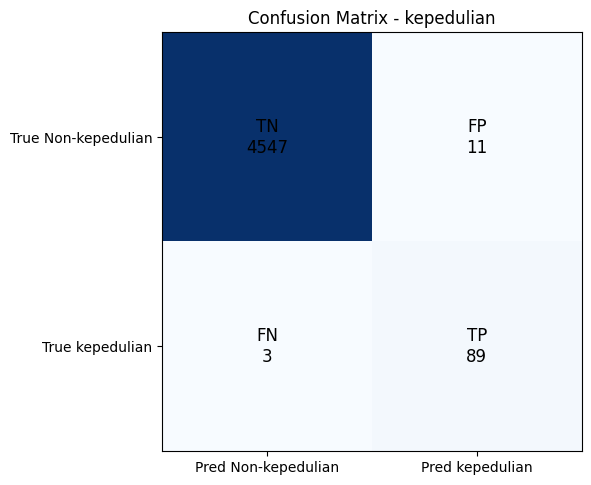

best_F1 0.9270833333333334
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'kepedulian' to: /content/drive/MyDrive/moralbert_cahya/kepedulian
Epoch: 2


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9430051813471503

Classification Report:
                precision    recall  f1-score   support

Non-kepedulian       1.00      1.00      1.00      4558
    kepedulian       0.90      0.99      0.94        92

      accuracy                           1.00      4650
     macro avg       0.95      0.99      0.97      4650
  weighted avg       1.00      1.00      1.00      4650


Train loss: 0.360993551623688
Validation loss: 0.3264857861389409


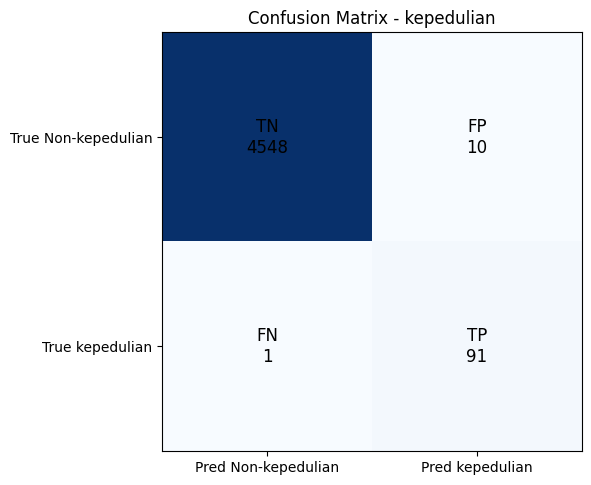

best_F1 0.9430051813471503
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'kepedulian' to: /content/drive/MyDrive/moralbert_cahya/kepedulian
Epoch: 3


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9732620320855615

Classification Report:
                precision    recall  f1-score   support

Non-kepedulian       1.00      1.00      1.00      4558
    kepedulian       0.96      0.99      0.97        92

      accuracy                           1.00      4650
     macro avg       0.98      0.99      0.99      4650
  weighted avg       1.00      1.00      1.00      4650


Train loss: 0.34185509636088474
Validation loss: 0.33544924978128415


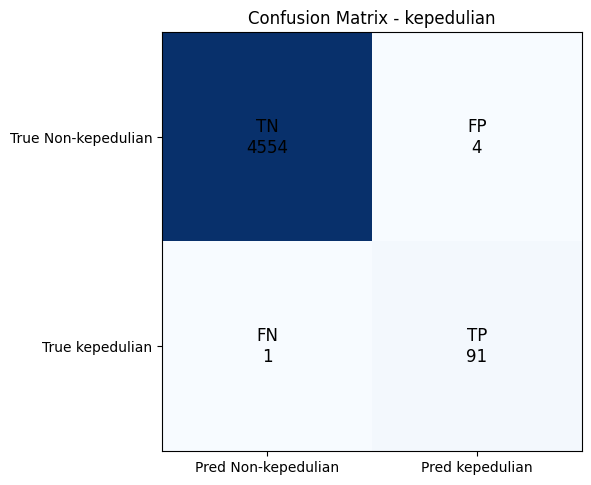

best_F1 0.9732620320855615
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'kepedulian' to: /content/drive/MyDrive/moralbert_cahya/kepedulian
Epoch: 4


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9782608695652174

Classification Report:
                precision    recall  f1-score   support

Non-kepedulian       1.00      1.00      1.00      4558
    kepedulian       0.98      0.98      0.98        92

      accuracy                           1.00      4650
     macro avg       0.99      0.99      0.99      4650
  weighted avg       1.00      1.00      1.00      4650


Train loss: 0.33881377481942737
Validation loss: 0.33539718655786155


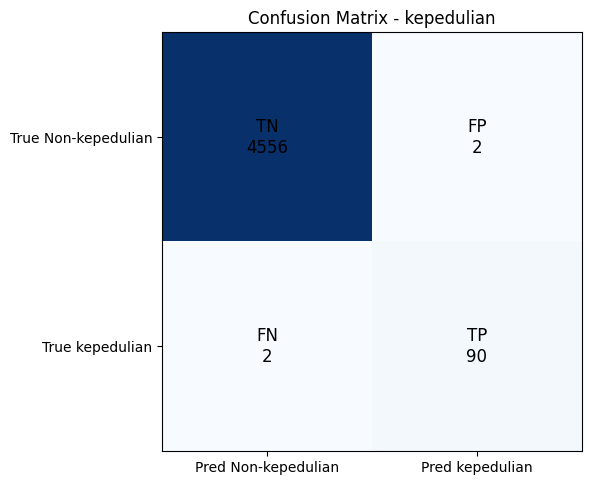

best_F1 0.9782608695652174
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'kepedulian' to: /content/drive/MyDrive/moralbert_cahya/kepedulian
Epoch: 5


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9837837837837838

Classification Report:
                precision    recall  f1-score   support

Non-kepedulian       1.00      1.00      1.00      4558
    kepedulian       0.98      0.99      0.98        92

      accuracy                           1.00      4650
     macro avg       0.99      0.99      0.99      4650
  weighted avg       1.00      1.00      1.00      4650


Train loss: 0.33467782935190077
Validation loss: 0.3285593266544473


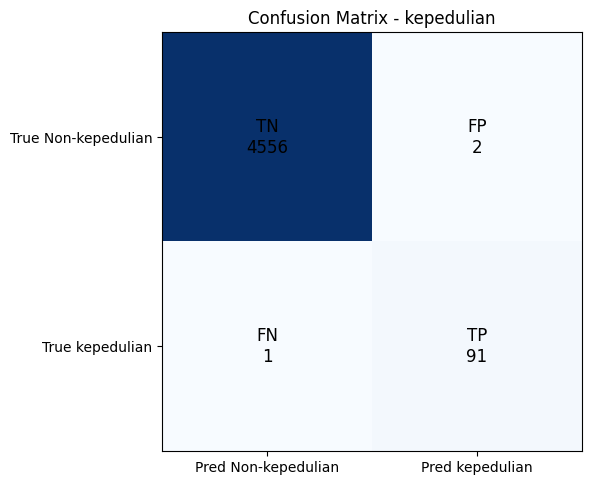

best_F1 0.9837837837837838
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'kepedulian' to: /content/drive/MyDrive/moralbert_cahya/kepedulian
Models for predicting moral dimension with BERT Base
Label: menyakiti
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cahya/bert-base-indonesian-1.5G
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Epochs for menyakiti:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8556701030927835

Classification Report:
               precision    recall  f1-score   support

Non-menyakiti       1.00      0.99      1.00      4563
    menyakiti       0.78      0.95      0.86        87

     accuracy                           0.99      4650
    macro avg       0.89      0.97      0.93      4650
 weighted avg       0.99      0.99      0.99      4650


Train loss: 0.49451022056393446
Validation loss: 0.37287372647691835


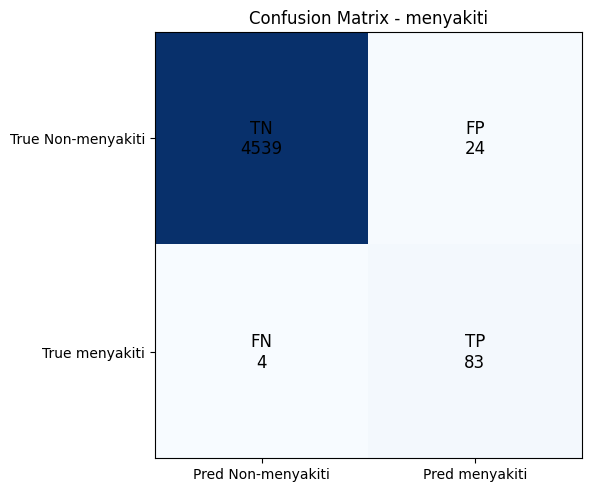

best_F1 0.8556701030927835
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'menyakiti' to: /content/drive/MyDrive/moralbert_cahya/menyakiti
Epoch: 2


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8829787234042553

Classification Report:
               precision    recall  f1-score   support

Non-menyakiti       1.00      1.00      1.00      4563
    menyakiti       0.82      0.95      0.88        87

     accuracy                           1.00      4650
    macro avg       0.91      0.98      0.94      4650
 weighted avg       1.00      1.00      1.00      4650


Train loss: 0.37829694659260976
Validation loss: 0.3670908959256005


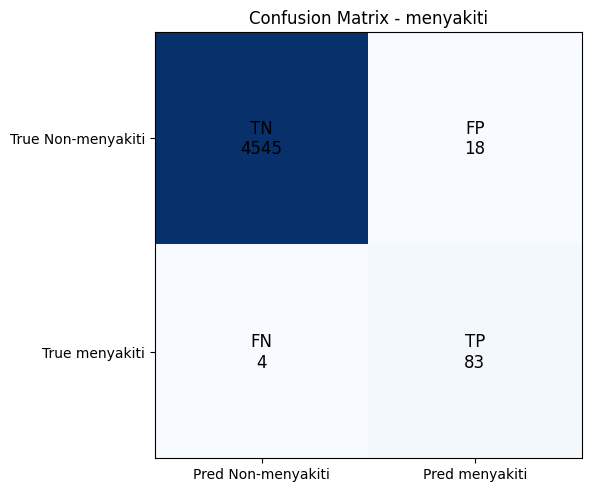

best_F1 0.8829787234042553
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'menyakiti' to: /content/drive/MyDrive/moralbert_cahya/menyakiti
Epoch: 3


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9120879120879121

Classification Report:
               precision    recall  f1-score   support

Non-menyakiti       1.00      1.00      1.00      4563
    menyakiti       0.87      0.95      0.91        87

     accuracy                           1.00      4650
    macro avg       0.94      0.98      0.96      4650
 weighted avg       1.00      1.00      1.00      4650


Train loss: 0.36091492305207845
Validation loss: 0.3569655246341351


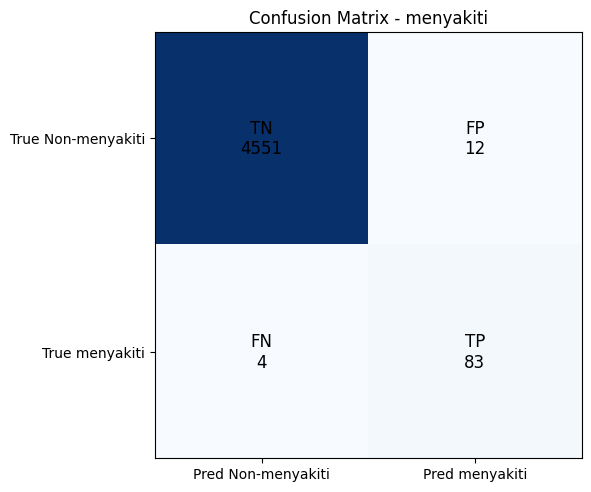

best_F1 0.9120879120879121
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'menyakiti' to: /content/drive/MyDrive/moralbert_cahya/menyakiti
Epoch: 4


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8829787234042553

Classification Report:
               precision    recall  f1-score   support

Non-menyakiti       1.00      1.00      1.00      4563
    menyakiti       0.82      0.95      0.88        87

     accuracy                           1.00      4650
    macro avg       0.91      0.98      0.94      4650
 weighted avg       1.00      1.00      1.00      4650


Train loss: 0.34439103370684543
Validation loss: 0.3682111996350829


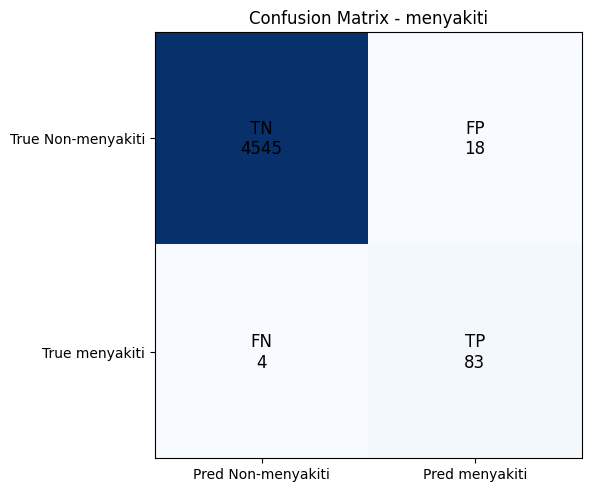

Epoch: 5


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.907103825136612

Classification Report:
               precision    recall  f1-score   support

Non-menyakiti       1.00      1.00      1.00      4563
    menyakiti       0.86      0.95      0.91        87

     accuracy                           1.00      4650
    macro avg       0.93      0.98      0.95      4650
 weighted avg       1.00      1.00      1.00      4650


Train loss: 0.3355219819273092
Validation loss: 0.3663960365495321


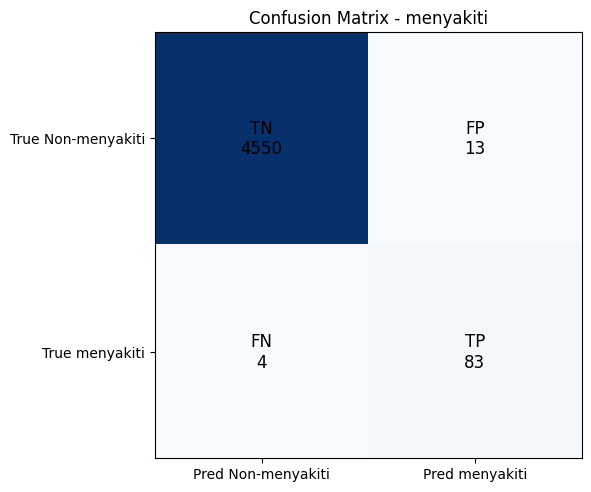

Models for predicting moral dimension with BERT Base
Label: keadilan
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cahya/bert-base-indonesian-1.5G
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cahya/bert-base-indonesian-1.5G
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epochs for keadilan:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.7468354430379747

Classification Report:
              precision    recall  f1-score   support

Non-keadilan       1.00      0.99      1.00      4576
    keadilan       0.70      0.80      0.75        74

    accuracy                           0.99      4650
   macro avg       0.85      0.90      0.87      4650
weighted avg       0.99      0.99      0.99      4650


Train loss: 0.5709313681334744
Validation loss: 0.4656789593680208


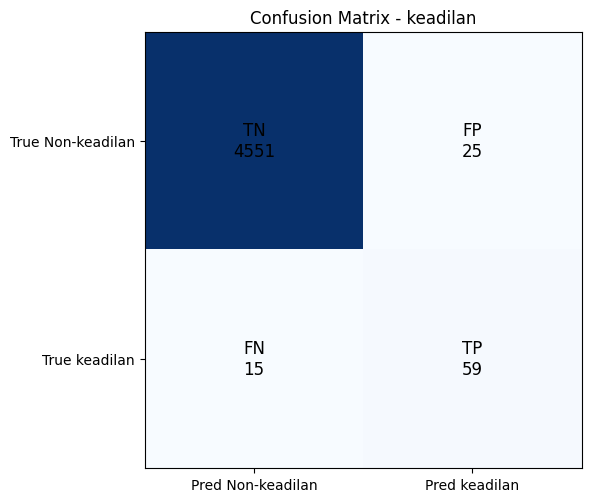

best_F1 0.7468354430379747
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'keadilan' to: /content/drive/MyDrive/moralbert_cahya/keadilan
Epoch: 2


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.7870967741935484

Classification Report:
              precision    recall  f1-score   support

Non-keadilan       1.00      1.00      1.00      4576
    keadilan       0.75      0.82      0.79        74

    accuracy                           0.99      4650
   macro avg       0.88      0.91      0.89      4650
weighted avg       0.99      0.99      0.99      4650


Train loss: 0.40514966517507467
Validation loss: 0.4974788082219481


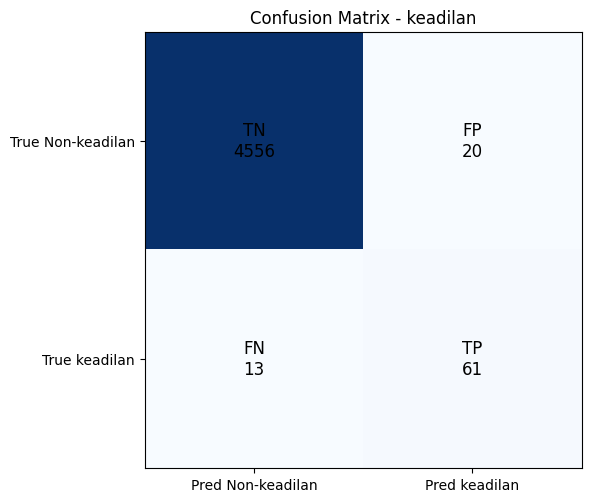

best_F1 0.7870967741935484
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'keadilan' to: /content/drive/MyDrive/moralbert_cahya/keadilan
Epoch: 3


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.504

Classification Report:
              precision    recall  f1-score   support

Non-keadilan       1.00      0.98      0.99      4576
    keadilan       0.36      0.85      0.50        74

    accuracy                           0.97      4650
   macro avg       0.68      0.91      0.75      4650
weighted avg       0.99      0.97      0.98      4650


Train loss: 0.3799707837793608
Validation loss: 0.47212515817475076


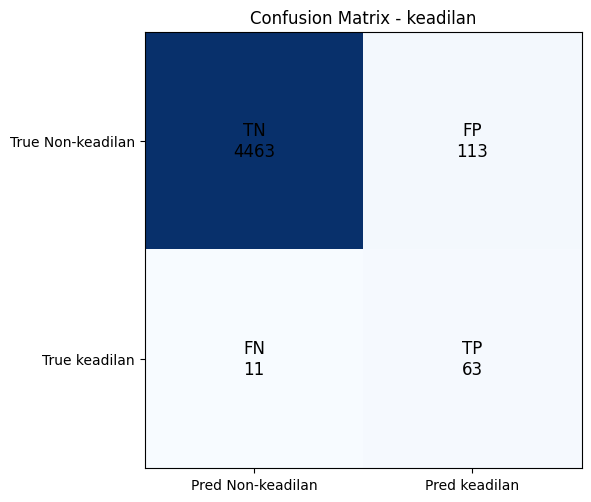

Epoch: 4


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.7945205479452054

Classification Report:
              precision    recall  f1-score   support

Non-keadilan       1.00      1.00      1.00      4576
    keadilan       0.81      0.78      0.79        74

    accuracy                           0.99      4650
   macro avg       0.90      0.89      0.90      4650
weighted avg       0.99      0.99      0.99      4650


Train loss: 0.35410981165983507
Validation loss: 0.5477075311531316


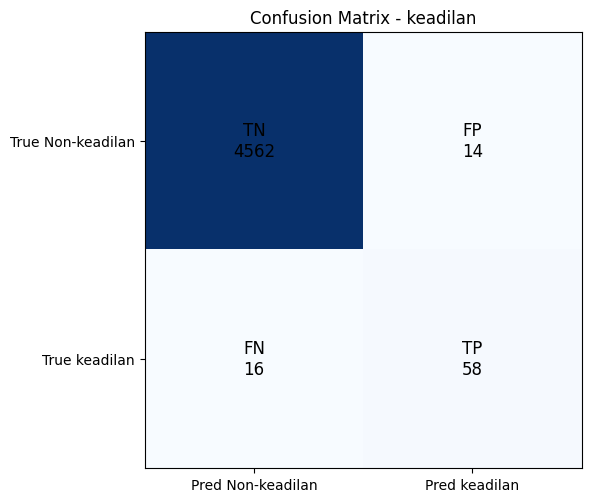

best_F1 0.7945205479452054
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'keadilan' to: /content/drive/MyDrive/moralbert_cahya/keadilan
Epoch: 5


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.7612903225806451

Classification Report:
              precision    recall  f1-score   support

Non-keadilan       1.00      1.00      1.00      4576
    keadilan       0.73      0.80      0.76        74

    accuracy                           0.99      4650
   macro avg       0.86      0.90      0.88      4650
weighted avg       0.99      0.99      0.99      4650


Train loss: 0.34796981788973097
Validation loss: 0.5514305666140265


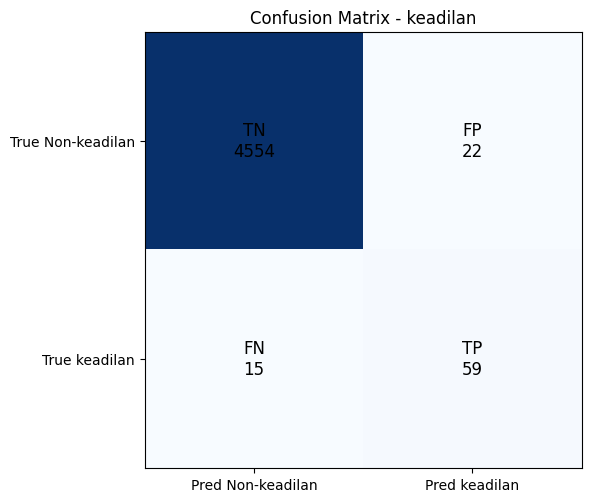

Models for predicting moral dimension with BERT Base
Label: kecurangan
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cahya/bert-base-indonesian-1.5G
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cahya/bert-base-indonesian-1.5G
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epochs for kecurangan:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.7692307692307693

Classification Report:
                precision    recall  f1-score   support

Non-kecurangan       1.00      1.00      1.00      4633
    kecurangan       0.68      0.88      0.77        17

      accuracy                           1.00      4650
     macro avg       0.84      0.94      0.88      4650
  weighted avg       1.00      1.00      1.00      4650


Train loss: 0.490926063557893
Validation loss: 0.3453052927743119


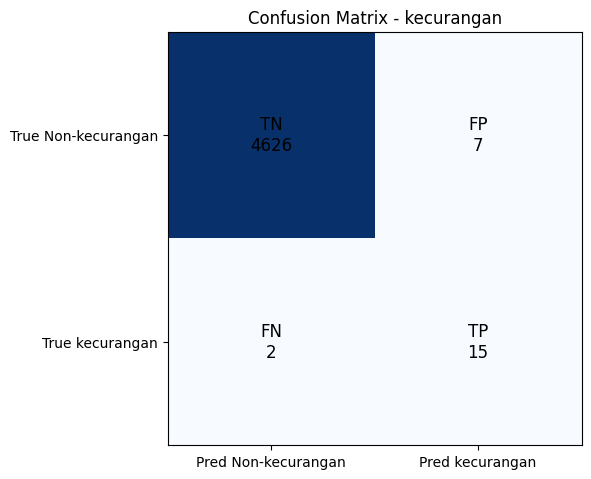

best_F1 0.7692307692307693
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'kecurangan' to: /content/drive/MyDrive/moralbert_cahya/kecurangan
Epoch: 2


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.5573770491803278

Classification Report:
                precision    recall  f1-score   support

Non-kecurangan       1.00      0.99      1.00      4633
    kecurangan       0.39      1.00      0.56        17

      accuracy                           0.99      4650
     macro avg       0.69      1.00      0.78      4650
  weighted avg       1.00      0.99      1.00      4650


Train loss: 0.35725169623092856
Validation loss: 0.33526959144782364


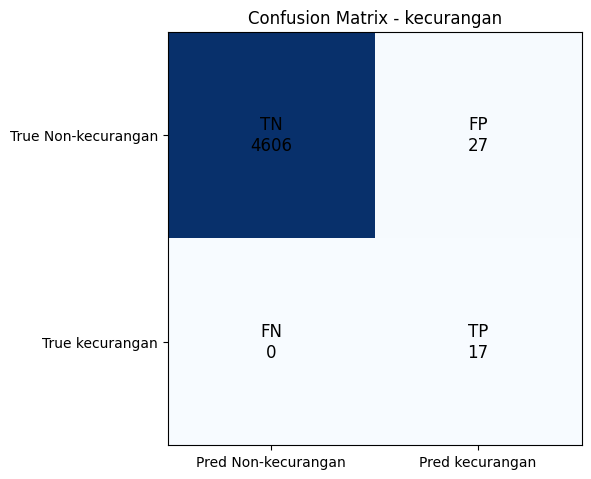

Epoch: 3


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.85

Classification Report:
                precision    recall  f1-score   support

Non-kecurangan       1.00      1.00      1.00      4633
    kecurangan       0.74      1.00      0.85        17

      accuracy                           1.00      4650
     macro avg       0.87      1.00      0.92      4650
  weighted avg       1.00      1.00      1.00      4650


Train loss: 0.3390840636125845
Validation loss: 0.3181847599158992


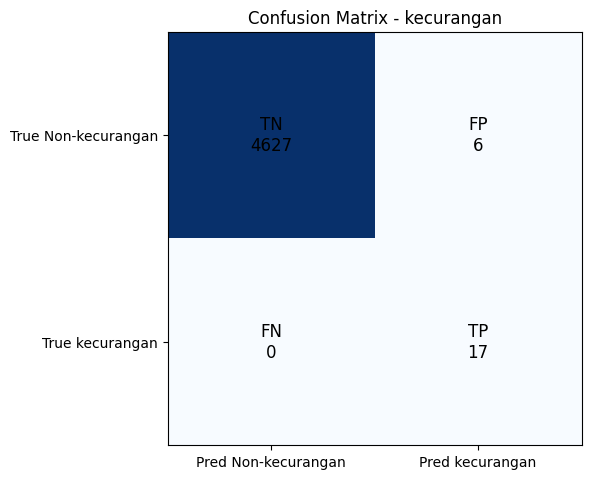

best_F1 0.85
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'kecurangan' to: /content/drive/MyDrive/moralbert_cahya/kecurangan
Epoch: 4


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.85

Classification Report:
                precision    recall  f1-score   support

Non-kecurangan       1.00      1.00      1.00      4633
    kecurangan       0.74      1.00      0.85        17

      accuracy                           1.00      4650
     macro avg       0.87      1.00      0.92      4650
  weighted avg       1.00      1.00      1.00      4650


Train loss: 0.3287456090708591
Validation loss: 0.3171034340596281


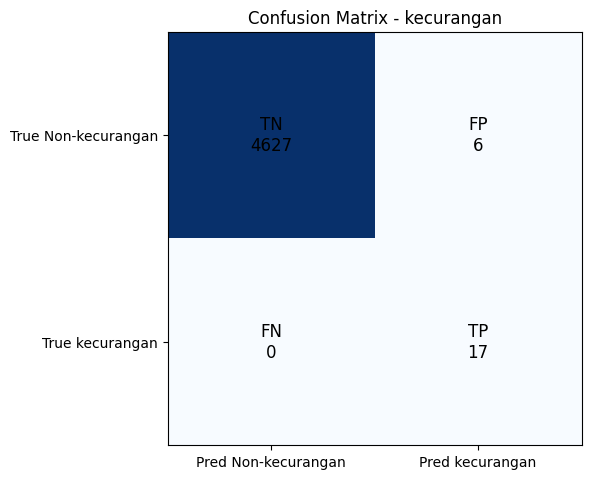

Epoch: 5


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.918918918918919

Classification Report:
                precision    recall  f1-score   support

Non-kecurangan       1.00      1.00      1.00      4633
    kecurangan       0.85      1.00      0.92        17

      accuracy                           1.00      4650
     macro avg       0.93      1.00      0.96      4650
  weighted avg       1.00      1.00      1.00      4650


Train loss: 0.3268461284817854
Validation loss: 0.3148650612003615


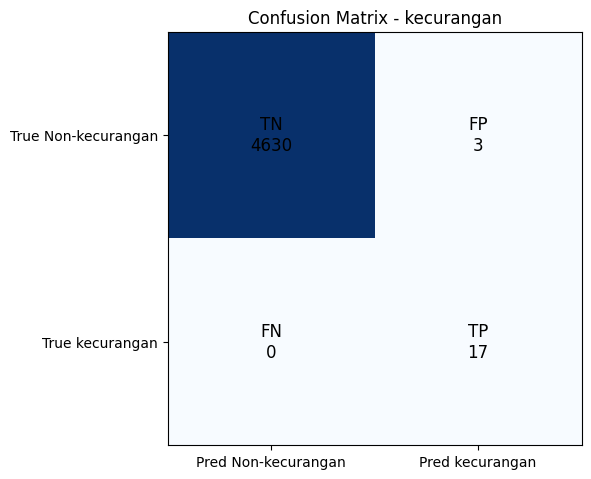

best_F1 0.918918918918919
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'kecurangan' to: /content/drive/MyDrive/moralbert_cahya/kecurangan
Models for predicting moral dimension with BERT Base
Label: loyalitas
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cahya/bert-base-indonesian-1.5G
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Epochs for loyalitas:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.6545454545454545

Classification Report:
               precision    recall  f1-score   support

Non-loyalitas       1.00      1.00      1.00      4623
    loyalitas       0.64      0.67      0.65        27

     accuracy                           1.00      4650
    macro avg       0.82      0.83      0.83      4650
 weighted avg       1.00      1.00      1.00      4650


Train loss: 0.4918767110551111
Validation loss: 0.4142751019844894


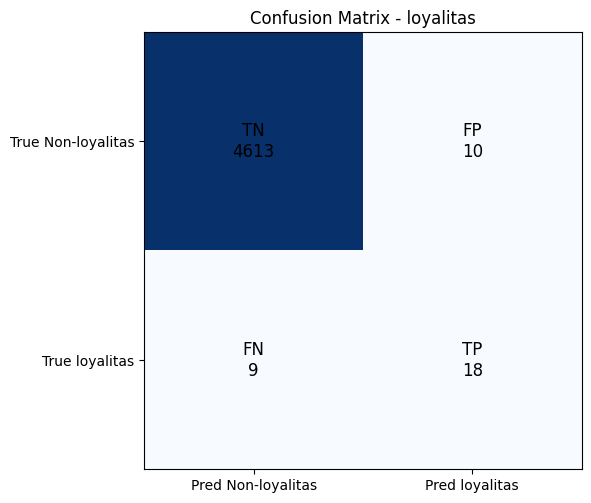

best_F1 0.6545454545454545
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'loyalitas' to: /content/drive/MyDrive/moralbert_cahya/loyalitas
Epoch: 2


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.6086956521739131

Classification Report:
               precision    recall  f1-score   support

Non-loyalitas       1.00      1.00      1.00      4623
    loyalitas       0.50      0.78      0.61        27

     accuracy                           0.99      4650
    macro avg       0.75      0.89      0.80      4650
 weighted avg       1.00      0.99      0.99      4650


Train loss: 0.3747795960919568
Validation loss: 0.3786223722282554


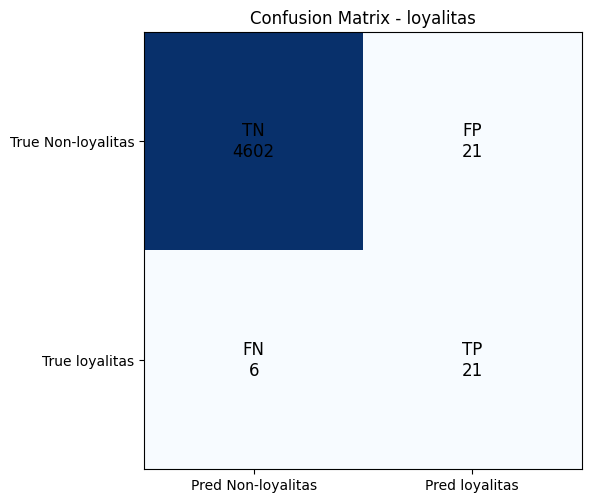

Epoch: 3


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.6197183098591549

Classification Report:
               precision    recall  f1-score   support

Non-loyalitas       1.00      1.00      1.00      4623
    loyalitas       0.50      0.81      0.62        27

     accuracy                           0.99      4650
    macro avg       0.75      0.91      0.81      4650
 weighted avg       1.00      0.99      0.99      4650


Train loss: 0.3517634240543648
Validation loss: 0.3726868507583526


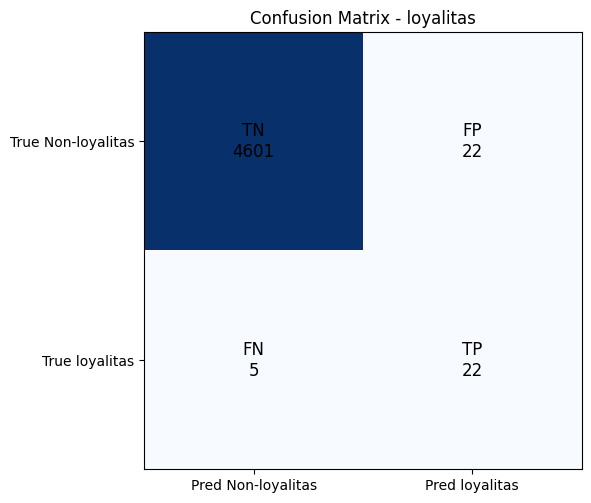

Epoch: 4


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.6885245901639344

Classification Report:
               precision    recall  f1-score   support

Non-loyalitas       1.00      1.00      1.00      4623
    loyalitas       0.62      0.78      0.69        27

     accuracy                           1.00      4650
    macro avg       0.81      0.89      0.84      4650
 weighted avg       1.00      1.00      1.00      4650


Train loss: 0.33962421463874526
Validation loss: 0.3854456253068144


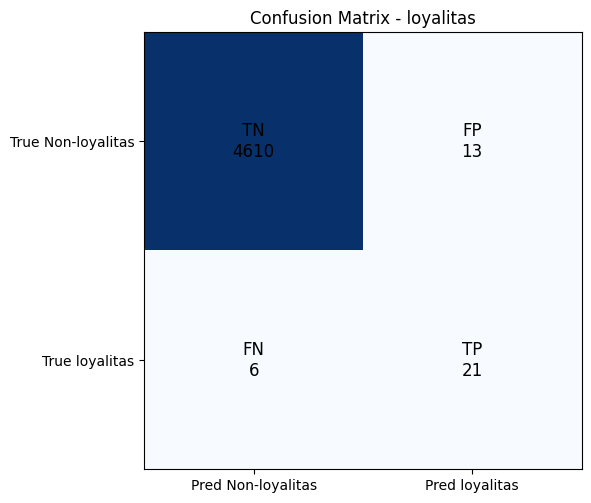

best_F1 0.6885245901639344
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'loyalitas' to: /content/drive/MyDrive/moralbert_cahya/loyalitas
Epoch: 5


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.7924528301886793

Classification Report:
               precision    recall  f1-score   support

Non-loyalitas       1.00      1.00      1.00      4623
    loyalitas       0.81      0.78      0.79        27

     accuracy                           1.00      4650
    macro avg       0.90      0.89      0.90      4650
 weighted avg       1.00      1.00      1.00      4650


Train loss: 0.3303047970052639
Validation loss: 0.39411151521803994


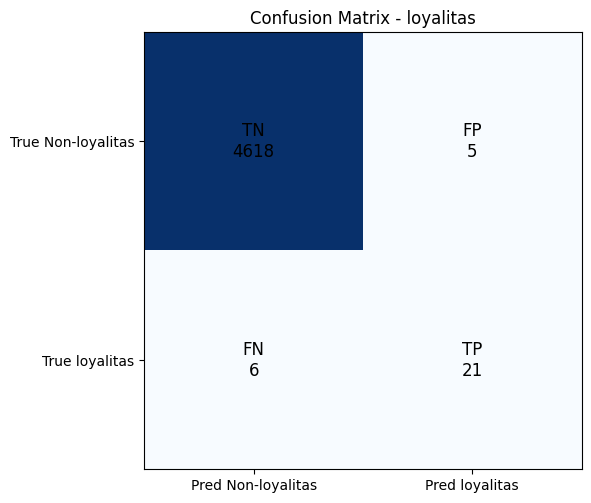

best_F1 0.7924528301886793
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'loyalitas' to: /content/drive/MyDrive/moralbert_cahya/loyalitas
Models for predicting moral dimension with BERT Base
Label: pengkhianatan
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cahya/bert-base-indonesian-1.5G
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Epochs for pengkhianatan:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.987012987012987

Classification Report:
                   precision    recall  f1-score   support

Non-pengkhianatan       1.00      1.00      1.00      4611
    pengkhianatan       1.00      0.97      0.99        39

         accuracy                           1.00      4650
        macro avg       1.00      0.99      0.99      4650
     weighted avg       1.00      1.00      1.00      4650


Train loss: 0.4598413124898335
Validation loss: 0.33683218599594744


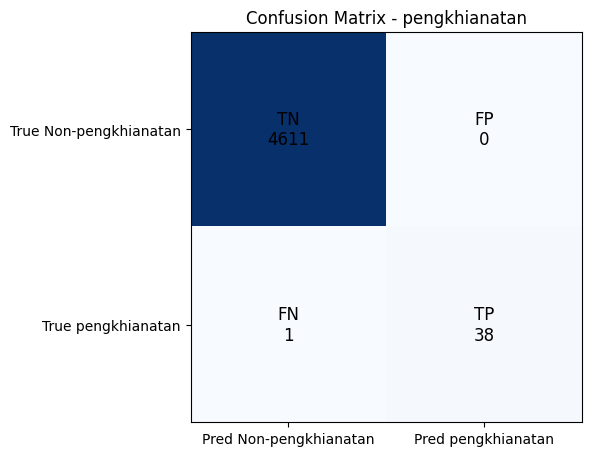

best_F1 0.987012987012987
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'pengkhianatan' to: /content/drive/MyDrive/moralbert_cahya/pengkhianatan
Epoch: 2


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.926829268292683

Classification Report:
                   precision    recall  f1-score   support

Non-pengkhianatan       1.00      1.00      1.00      4611
    pengkhianatan       0.88      0.97      0.93        39

         accuracy                           1.00      4650
        macro avg       0.94      0.99      0.96      4650
     weighted avg       1.00      1.00      1.00      4650


Train loss: 0.3494250471491498
Validation loss: 0.33925256491526706


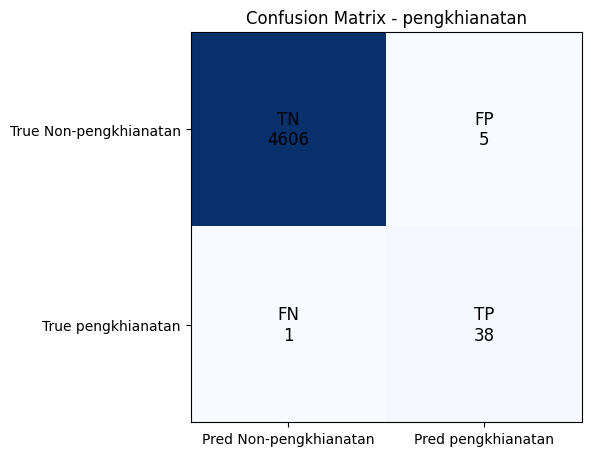

Epoch: 3


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9743589743589743

Classification Report:
                   precision    recall  f1-score   support

Non-pengkhianatan       1.00      1.00      1.00      4611
    pengkhianatan       0.97      0.97      0.97        39

         accuracy                           1.00      4650
        macro avg       0.99      0.99      0.99      4650
     weighted avg       1.00      1.00      1.00      4650


Train loss: 0.32904969869455386
Validation loss: 0.33891831609801326


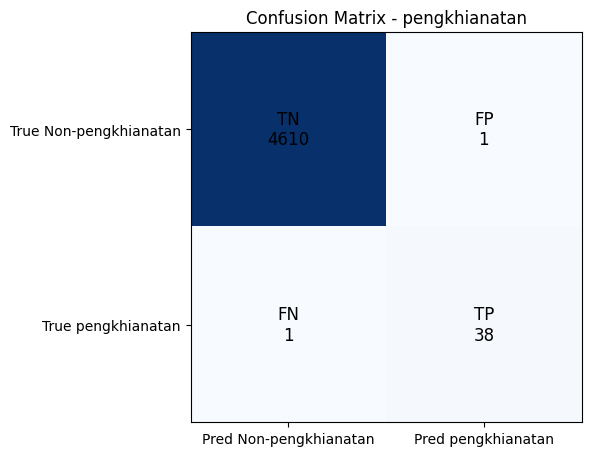

Epoch: 4


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9743589743589743

Classification Report:
                   precision    recall  f1-score   support

Non-pengkhianatan       1.00      1.00      1.00      4611
    pengkhianatan       0.97      0.97      0.97        39

         accuracy                           1.00      4650
        macro avg       0.99      0.99      0.99      4650
     weighted avg       1.00      1.00      1.00      4650


Train loss: 0.3267558365419622
Validation loss: 0.33957885477141414


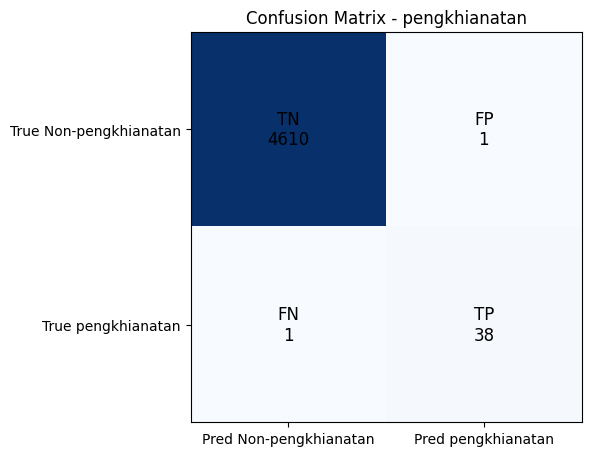

Epoch: 5


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9743589743589743

Classification Report:
                   precision    recall  f1-score   support

Non-pengkhianatan       1.00      1.00      1.00      4611
    pengkhianatan       0.97      0.97      0.97        39

         accuracy                           1.00      4650
        macro avg       0.99      0.99      0.99      4650
     weighted avg       1.00      1.00      1.00      4650


Train loss: 0.32546031029185446
Validation loss: 0.3395585927766623


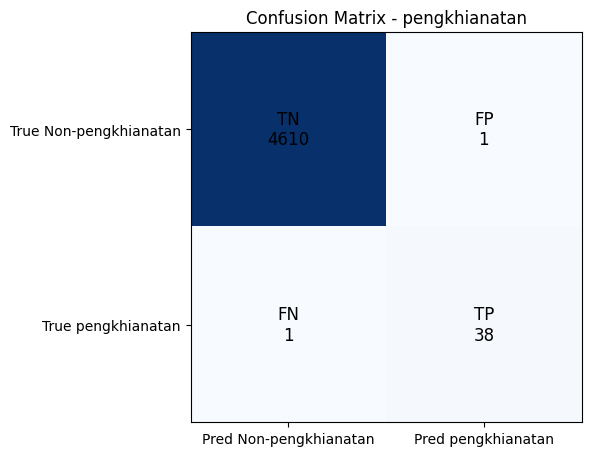

Models for predicting moral dimension with BERT Base
Label: otoritas
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cahya/bert-base-indonesian-1.5G
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cahya/bert-base-indonesian-1.5G
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epochs for otoritas:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9215686274509803

Classification Report:
              precision    recall  f1-score   support

Non-otoritas       1.00      1.00      1.00      4506
    otoritas       0.87      0.98      0.92       144

    accuracy                           0.99      4650
   macro avg       0.93      0.99      0.96      4650
weighted avg       1.00      0.99      0.99      4650


Train loss: 0.50731820383158
Validation loss: 0.36164503818525073


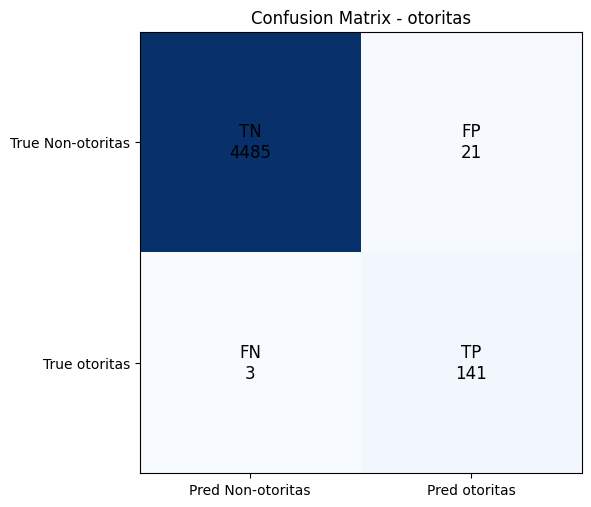

best_F1 0.9215686274509803
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'otoritas' to: /content/drive/MyDrive/moralbert_cahya/otoritas
Epoch: 2


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9281045751633987

Classification Report:
              precision    recall  f1-score   support

Non-otoritas       1.00      1.00      1.00      4506
    otoritas       0.88      0.99      0.93       144

    accuracy                           1.00      4650
   macro avg       0.94      0.99      0.96      4650
weighted avg       1.00      1.00      1.00      4650


Train loss: 0.3705231937117753
Validation loss: 0.3598563579964064


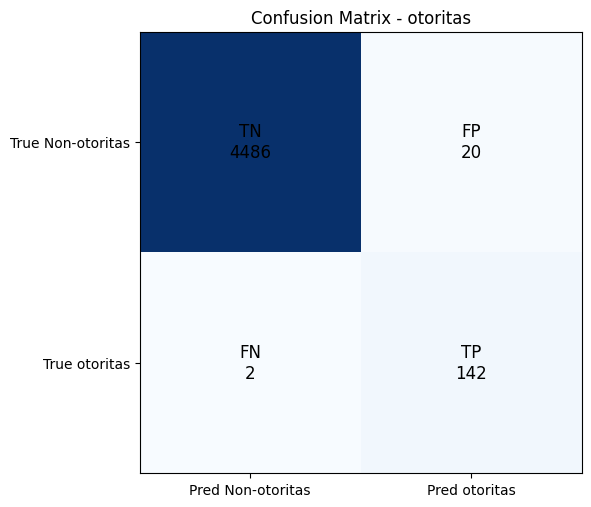

best_F1 0.9281045751633987
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'otoritas' to: /content/drive/MyDrive/moralbert_cahya/otoritas
Epoch: 3


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9102564102564102

Classification Report:
              precision    recall  f1-score   support

Non-otoritas       1.00      0.99      1.00      4506
    otoritas       0.85      0.99      0.91       144

    accuracy                           0.99      4650
   macro avg       0.92      0.99      0.95      4650
weighted avg       0.99      0.99      0.99      4650


Train loss: 0.361157476697005
Validation loss: 0.3579849530126631


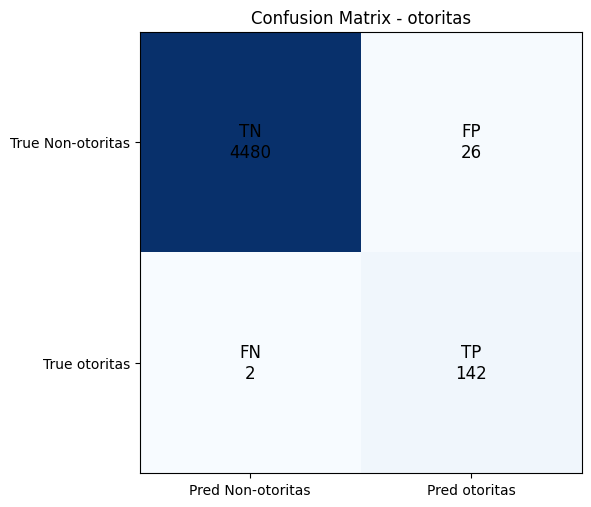

Epoch: 4


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9403973509933775

Classification Report:
              precision    recall  f1-score   support

Non-otoritas       1.00      1.00      1.00      4506
    otoritas       0.90      0.99      0.94       144

    accuracy                           1.00      4650
   macro avg       0.95      0.99      0.97      4650
weighted avg       1.00      1.00      1.00      4650


Train loss: 0.35377652378094576
Validation loss: 0.35488893383557035


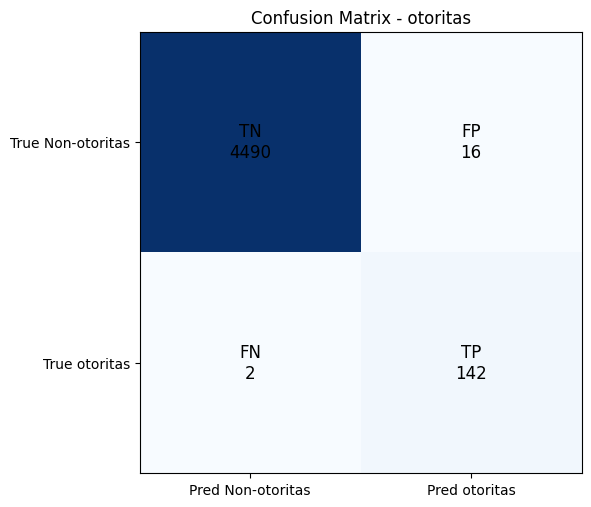

best_F1 0.9403973509933775
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'otoritas' to: /content/drive/MyDrive/moralbert_cahya/otoritas
Epoch: 5


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9466666666666667

Classification Report:
              precision    recall  f1-score   support

Non-otoritas       1.00      1.00      1.00      4506
    otoritas       0.91      0.99      0.95       144

    accuracy                           1.00      4650
   macro avg       0.95      0.99      0.97      4650
weighted avg       1.00      1.00      1.00      4650


Train loss: 0.3456945500800247
Validation loss: 0.3547932514824818


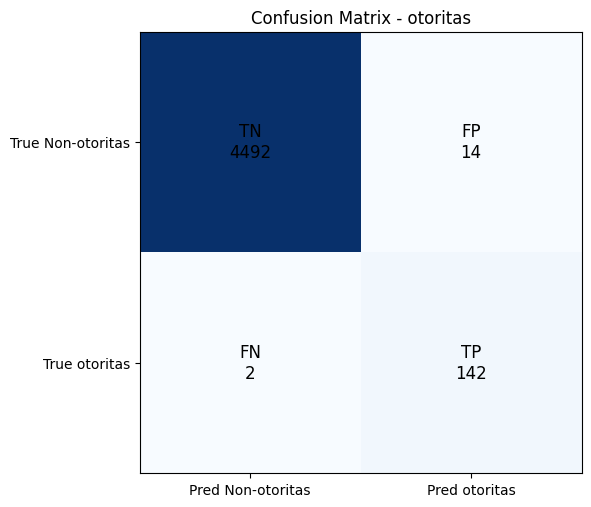

best_F1 0.9466666666666667
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'otoritas' to: /content/drive/MyDrive/moralbert_cahya/otoritas
Models for predicting moral dimension with BERT Base
Label: pembangkangan
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cahya/bert-base-indonesian-1.5G
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Epochs for pembangkangan:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.5625

Classification Report:
                   precision    recall  f1-score   support

Non-pembangkangan       1.00      0.99      1.00      4630
    pembangkangan       0.41      0.90      0.56        20

         accuracy                           0.99      4650
        macro avg       0.70      0.95      0.78      4650
     weighted avg       1.00      0.99      1.00      4650


Train loss: 0.5132918562852199
Validation loss: 0.36949830253918964


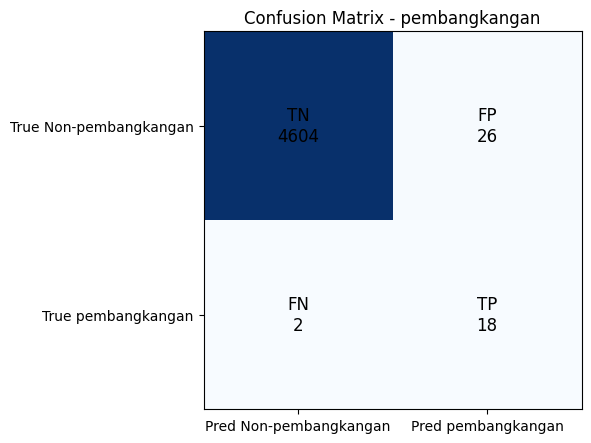

best_F1 0.5625
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'pembangkangan' to: /content/drive/MyDrive/moralbert_cahya/pembangkangan
Epoch: 2


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9230769230769231

Classification Report:
                   precision    recall  f1-score   support

Non-pembangkangan       1.00      1.00      1.00      4630
    pembangkangan       0.95      0.90      0.92        20

         accuracy                           1.00      4650
        macro avg       0.97      0.95      0.96      4650
     weighted avg       1.00      1.00      1.00      4650


Train loss: 0.3568165178249749
Validation loss: 0.35839453257645937


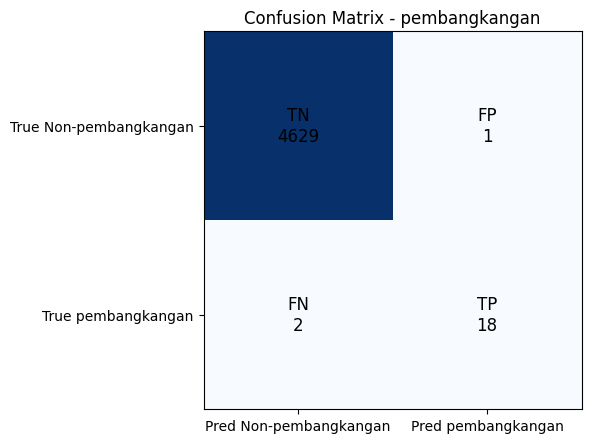

best_F1 0.9230769230769231
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'pembangkangan' to: /content/drive/MyDrive/moralbert_cahya/pembangkangan
Epoch: 3


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9230769230769231

Classification Report:
                   precision    recall  f1-score   support

Non-pembangkangan       1.00      1.00      1.00      4630
    pembangkangan       0.95      0.90      0.92        20

         accuracy                           1.00      4650
        macro avg       0.97      0.95      0.96      4650
     weighted avg       1.00      1.00      1.00      4650


Train loss: 0.34718333362815507
Validation loss: 0.355433303056304


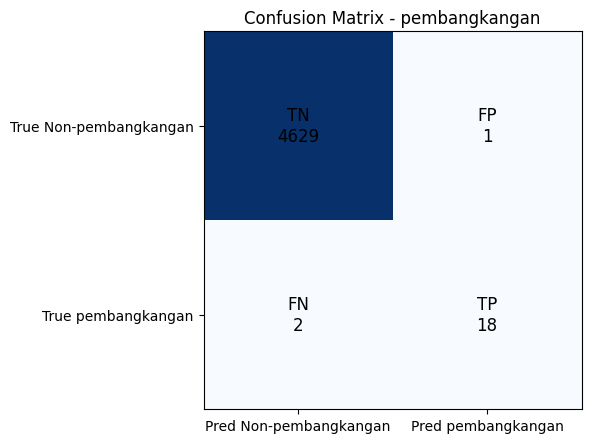

Epoch: 4


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9230769230769231

Classification Report:
                   precision    recall  f1-score   support

Non-pembangkangan       1.00      1.00      1.00      4630
    pembangkangan       0.95      0.90      0.92        20

         accuracy                           1.00      4650
        macro avg       0.97      0.95      0.96      4650
     weighted avg       1.00      1.00      1.00      4650


Train loss: 0.34439826859857947
Validation loss: 0.35702773590677794


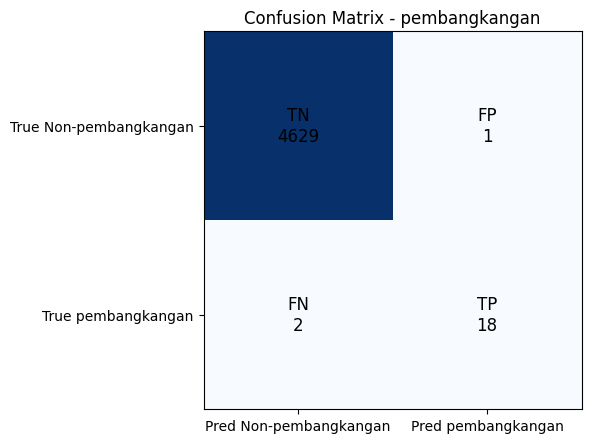

Epoch: 5


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9230769230769231

Classification Report:
                   precision    recall  f1-score   support

Non-pembangkangan       1.00      1.00      1.00      4630
    pembangkangan       0.95      0.90      0.92        20

         accuracy                           1.00      4650
        macro avg       0.97      0.95      0.96      4650
     weighted avg       1.00      1.00      1.00      4650


Train loss: 0.3408134117632822
Validation loss: 0.3562181197695716


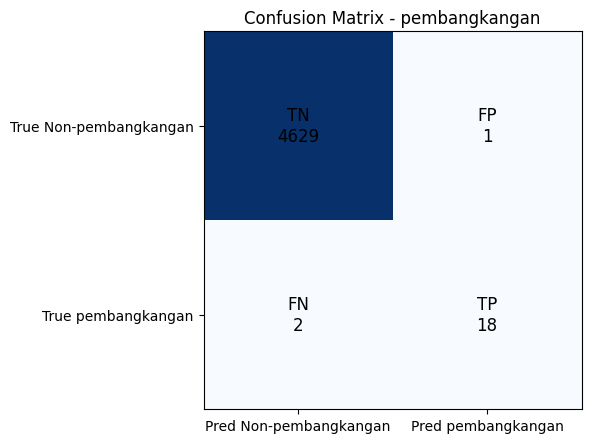

Models for predicting moral dimension with BERT Base
Label: kesucian
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cahya/bert-base-indonesian-1.5G
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cahya/bert-base-indonesian-1.5G
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epochs for kesucian:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.6209677419354839

Classification Report:
              precision    recall  f1-score   support

Non-kesucian       0.99      0.99      0.99      4542
    kesucian       0.55      0.71      0.62       108

    accuracy                           0.98      4650
   macro avg       0.77      0.85      0.81      4650
weighted avg       0.98      0.98      0.98      4650


Train loss: 0.6542828173239684
Validation loss: 0.5514342970249989


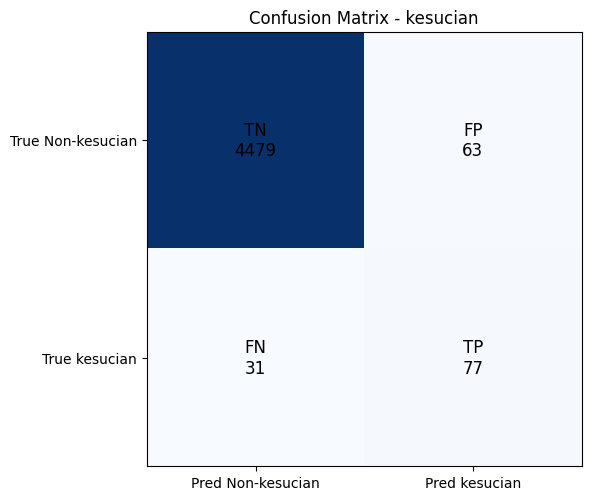

best_F1 0.6209677419354839
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'kesucian' to: /content/drive/MyDrive/moralbert_cahya/kesucian
Epoch: 2


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.5850340136054422

Classification Report:
              precision    recall  f1-score   support

Non-kesucian       1.00      0.98      0.99      4542
    kesucian       0.46      0.80      0.59       108

    accuracy                           0.97      4650
   macro avg       0.73      0.89      0.79      4650
weighted avg       0.98      0.97      0.98      4650


Train loss: 0.4781019778878957
Validation loss: 0.5157802651837929


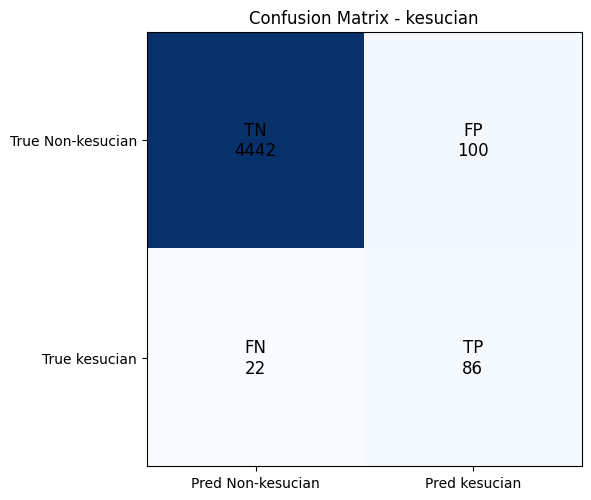

Epoch: 3


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.5714285714285714

Classification Report:
              precision    recall  f1-score   support

Non-kesucian       0.99      0.98      0.99      4542
    kesucian       0.45      0.78      0.57       108

    accuracy                           0.97      4650
   macro avg       0.72      0.88      0.78      4650
weighted avg       0.98      0.97      0.98      4650


Train loss: 0.39409282365341386
Validation loss: 0.5516357378861338


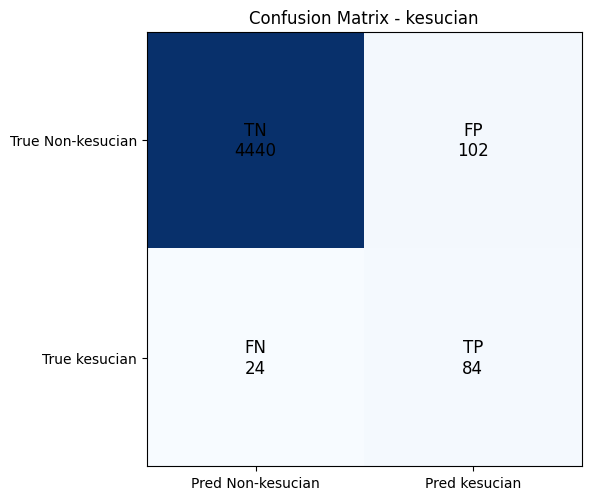

Epoch: 4


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.6808510638297872

Classification Report:
              precision    recall  f1-score   support

Non-kesucian       0.99      0.99      0.99      4542
    kesucian       0.63      0.74      0.68       108

    accuracy                           0.98      4650
   macro avg       0.81      0.87      0.84      4650
weighted avg       0.99      0.98      0.98      4650


Train loss: 0.35509325147495124
Validation loss: 0.6132704735416727


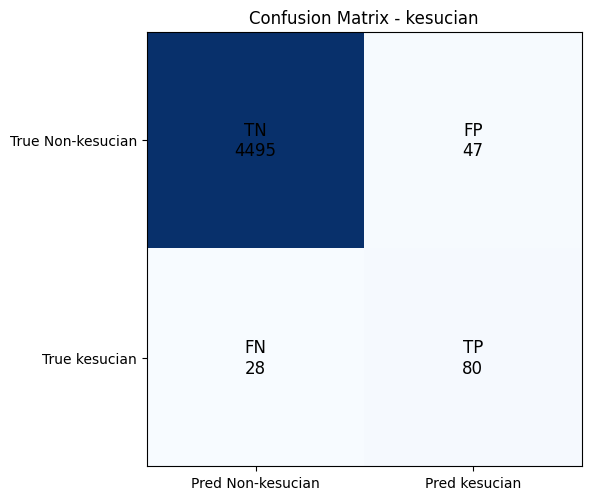

best_F1 0.6808510638297872
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'kesucian' to: /content/drive/MyDrive/moralbert_cahya/kesucian
Epoch: 5


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.6893617021276596

Classification Report:
              precision    recall  f1-score   support

Non-kesucian       0.99      0.99      0.99      4542
    kesucian       0.64      0.75      0.69       108

    accuracy                           0.98      4650
   macro avg       0.82      0.87      0.84      4650
weighted avg       0.99      0.98      0.98      4650


Train loss: 0.34355213292590114
Validation loss: 0.6298683445478223


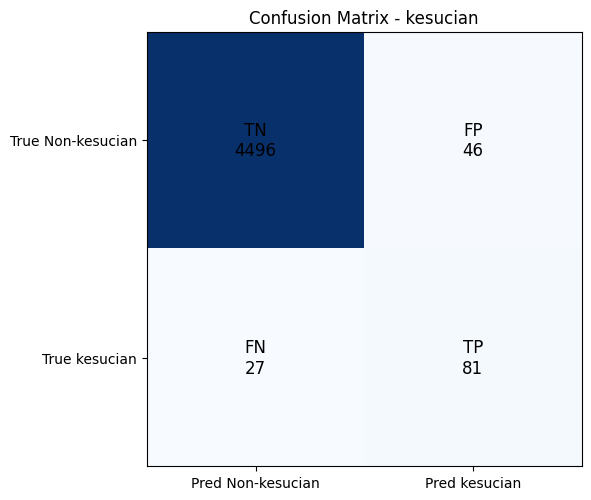

best_F1 0.6893617021276596
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'kesucian' to: /content/drive/MyDrive/moralbert_cahya/kesucian
Models for predicting moral dimension with BERT Base
Label: kemerosotan
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cahya/bert-base-indonesian-1.5G
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Epochs for kemerosotan:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.2222222222222222

Classification Report:
                 precision    recall  f1-score   support

Non-kemerosotan       1.00      0.98      0.99      4629
    kemerosotan       0.13      0.76      0.22        21

       accuracy                           0.98      4650
      macro avg       0.56      0.87      0.60      4650
   weighted avg       0.99      0.98      0.98      4650


Train loss: 0.5448424893264
Validation loss: 0.41457865881346345


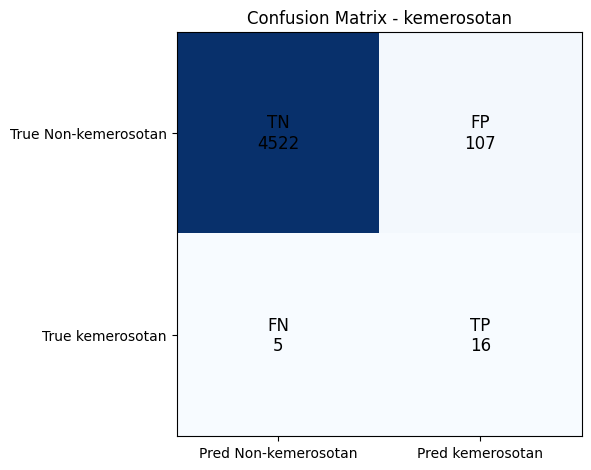

best_F1 0.2222222222222222
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'kemerosotan' to: /content/drive/MyDrive/moralbert_cahya/kemerosotan
Epoch: 2


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.926829268292683

Classification Report:
                 precision    recall  f1-score   support

Non-kemerosotan       1.00      1.00      1.00      4629
    kemerosotan       0.95      0.90      0.93        21

       accuracy                           1.00      4650
      macro avg       0.97      0.95      0.96      4650
   weighted avg       1.00      1.00      1.00      4650


Train loss: 0.3951449322218743
Validation loss: 0.3416977101789717


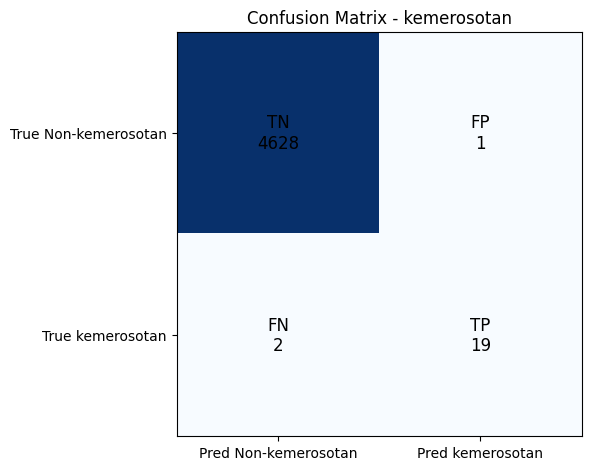

best_F1 0.926829268292683
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'kemerosotan' to: /content/drive/MyDrive/moralbert_cahya/kemerosotan
Epoch: 3


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8421052631578947

Classification Report:
                 precision    recall  f1-score   support

Non-kemerosotan       1.00      1.00      1.00      4629
    kemerosotan       0.94      0.76      0.84        21

       accuracy                           1.00      4650
      macro avg       0.97      0.88      0.92      4650
   weighted avg       1.00      1.00      1.00      4650


Train loss: 0.35091076764379814
Validation loss: 0.3798069520709441


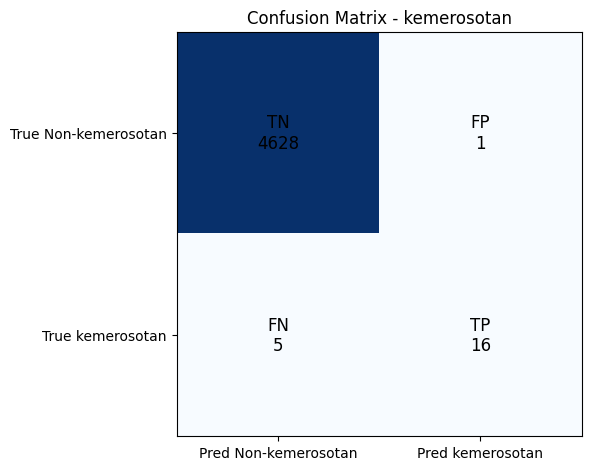

Epoch: 4


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8780487804878049

Classification Report:
                 precision    recall  f1-score   support

Non-kemerosotan       1.00      1.00      1.00      4629
    kemerosotan       0.90      0.86      0.88        21

       accuracy                           1.00      4650
      macro avg       0.95      0.93      0.94      4650
   weighted avg       1.00      1.00      1.00      4650


Train loss: 0.33110152537312265
Validation loss: 0.3479265595219799


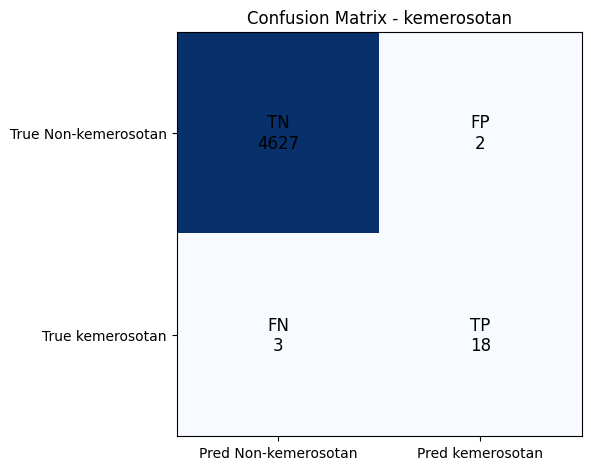

Epoch: 5


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8780487804878049

Classification Report:
                 precision    recall  f1-score   support

Non-kemerosotan       1.00      1.00      1.00      4629
    kemerosotan       0.90      0.86      0.88        21

       accuracy                           1.00      4650
      macro avg       0.95      0.93      0.94      4650
   weighted avg       1.00      1.00      1.00      4650


Train loss: 0.32907930193332796
Validation loss: 0.3489467512905802


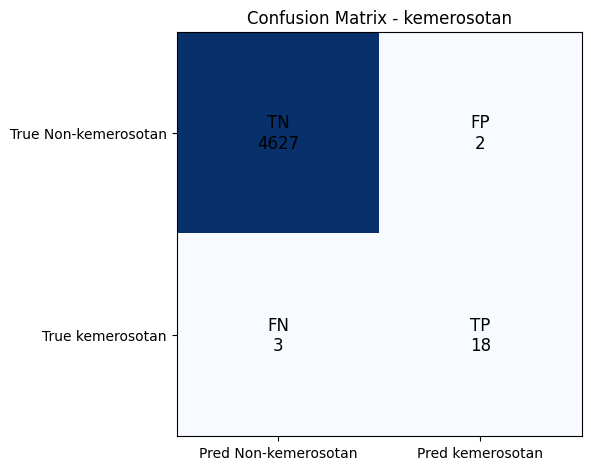

Models for predicting moral dimension with BERT Base
Label: kebebasan
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cahya/bert-base-indonesian-1.5G
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cahya/bert-base-indonesian-1.5G
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epochs for kebebasan:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9

Classification Report:
               precision    recall  f1-score   support

Non-kebebasan       1.00      1.00      1.00      4630
    kebebasan       0.90      0.90      0.90        20

     accuracy                           1.00      4650
    macro avg       0.95      0.95      0.95      4650
 weighted avg       1.00      1.00      1.00      4650


Train loss: 0.4693930207504246
Validation loss: 0.3482533966757588


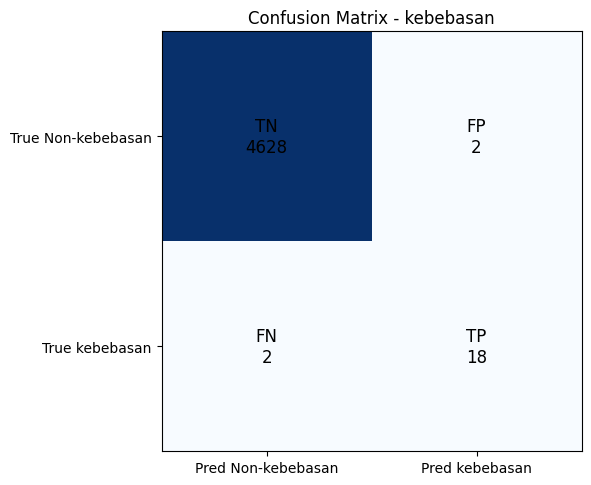

best_F1 0.9
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'kebebasan' to: /content/drive/MyDrive/moralbert_cahya/kebebasan
Epoch: 2


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8085106382978723

Classification Report:
               precision    recall  f1-score   support

Non-kebebasan       1.00      1.00      1.00      4630
    kebebasan       0.70      0.95      0.81        20

     accuracy                           1.00      4650
    macro avg       0.85      0.97      0.90      4650
 weighted avg       1.00      1.00      1.00      4650


Train loss: 0.3390561575174127
Validation loss: 0.3445699977915721


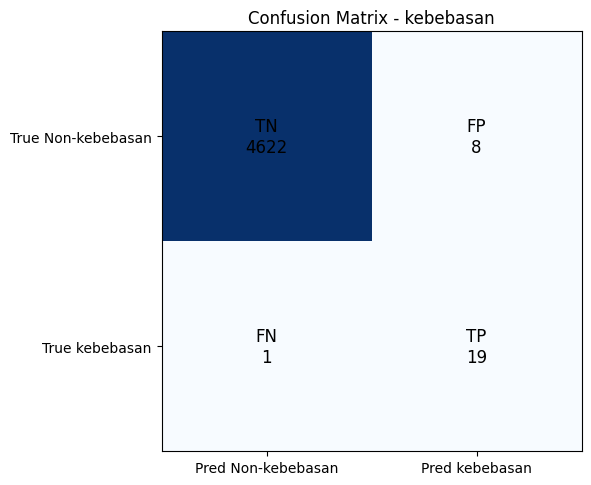

Epoch: 3


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.926829268292683

Classification Report:
               precision    recall  f1-score   support

Non-kebebasan       1.00      1.00      1.00      4630
    kebebasan       0.90      0.95      0.93        20

     accuracy                           1.00      4650
    macro avg       0.95      0.97      0.96      4650
 weighted avg       1.00      1.00      1.00      4650


Train loss: 0.339531551095195
Validation loss: 0.34090895034193586


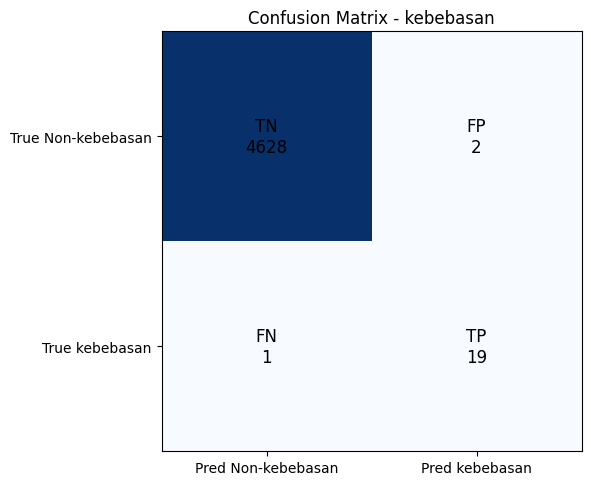

best_F1 0.926829268292683
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'kebebasan' to: /content/drive/MyDrive/moralbert_cahya/kebebasan
Epoch: 4


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.95

Classification Report:
               precision    recall  f1-score   support

Non-kebebasan       1.00      1.00      1.00      4630
    kebebasan       0.95      0.95      0.95        20

     accuracy                           1.00      4650
    macro avg       0.97      0.97      0.97      4650
 weighted avg       1.00      1.00      1.00      4650


Train loss: 0.3280899288422674
Validation loss: 0.3418930519077786


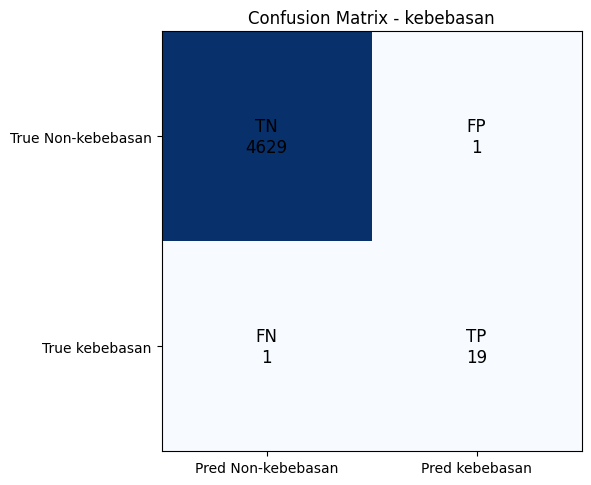

best_F1 0.95
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'kebebasan' to: /content/drive/MyDrive/moralbert_cahya/kebebasan
Epoch: 5


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.95

Classification Report:
               precision    recall  f1-score   support

Non-kebebasan       1.00      1.00      1.00      4630
    kebebasan       0.95      0.95      0.95        20

     accuracy                           1.00      4650
    macro avg       0.97      0.97      0.97      4650
 weighted avg       1.00      1.00      1.00      4650


Train loss: 0.32584121984750775
Validation loss: 0.3420785377730209


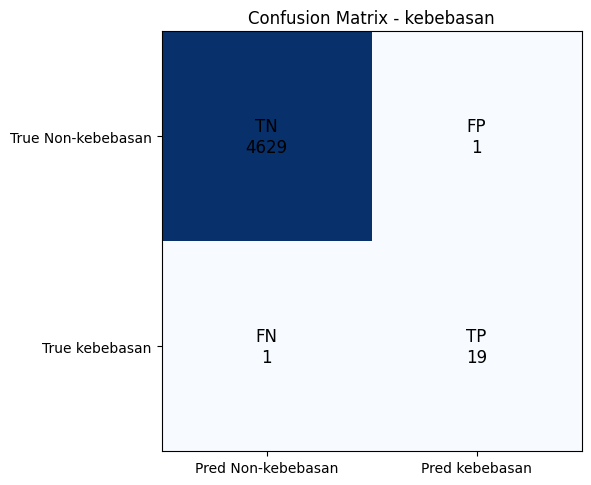

Models for predicting moral dimension with BERT Base
Label: penindasan
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cahya/bert-base-indonesian-1.5G
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cahya/bert-base-indonesian-1.5G
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epochs for penindasan:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8571428571428571

Classification Report:
                precision    recall  f1-score   support

Non-penindasan       1.00      1.00      1.00      4636
    penindasan       0.86      0.86      0.86        14

      accuracy                           1.00      4650
     macro avg       0.93      0.93      0.93      4650
  weighted avg       1.00      1.00      1.00      4650


Train loss: 0.4545921097002661
Validation loss: 0.3416815374520226


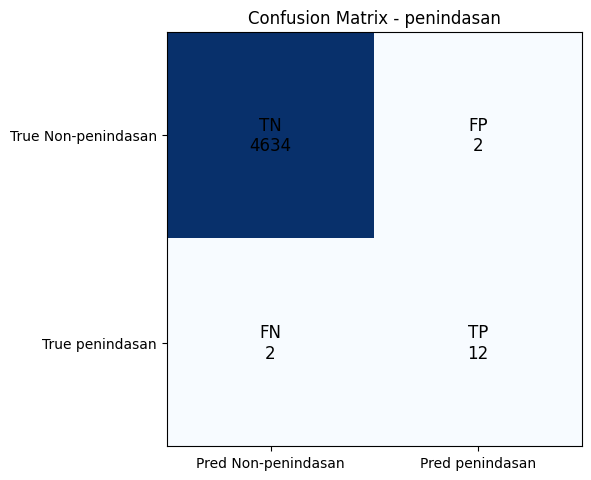

best_F1 0.8571428571428571
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'penindasan' to: /content/drive/MyDrive/moralbert_cahya/penindasan
Epoch: 2


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.7428571428571429

Classification Report:
                precision    recall  f1-score   support

Non-penindasan       1.00      1.00      1.00      4636
    penindasan       0.62      0.93      0.74        14

      accuracy                           1.00      4650
     macro avg       0.81      0.96      0.87      4650
  weighted avg       1.00      1.00      1.00      4650


Train loss: 0.3527190420305739
Validation loss: 0.34015668237332214


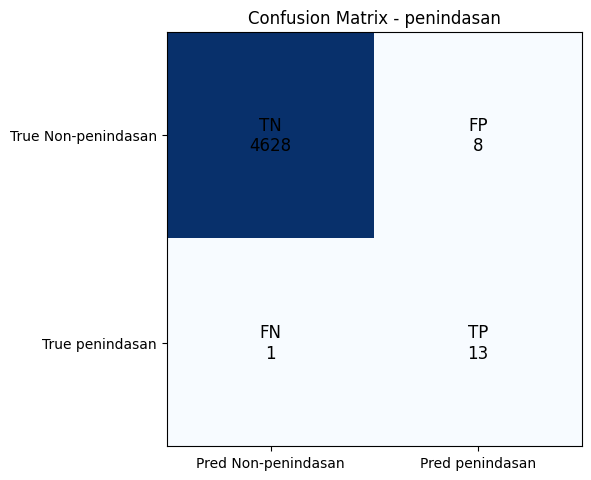

Epoch: 3


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8387096774193549

Classification Report:
                precision    recall  f1-score   support

Non-penindasan       1.00      1.00      1.00      4636
    penindasan       0.76      0.93      0.84        14

      accuracy                           1.00      4650
     macro avg       0.88      0.96      0.92      4650
  weighted avg       1.00      1.00      1.00      4650


Train loss: 0.3364105596433707
Validation loss: 0.34023036446767985


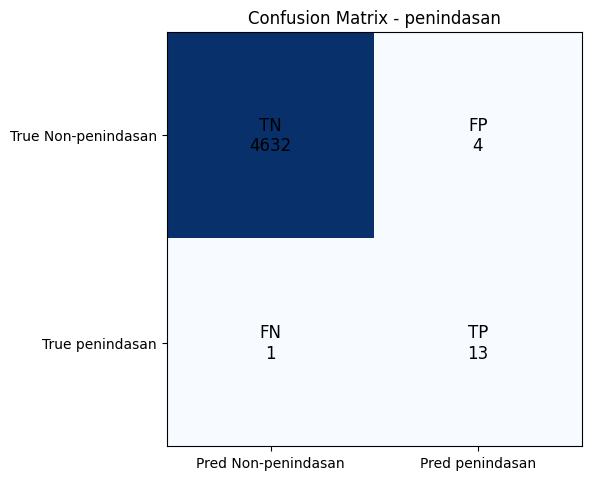

Epoch: 4


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8387096774193549

Classification Report:
                precision    recall  f1-score   support

Non-penindasan       1.00      1.00      1.00      4636
    penindasan       0.76      0.93      0.84        14

      accuracy                           1.00      4650
     macro avg       0.88      0.96      0.92      4650
  weighted avg       1.00      1.00      1.00      4650


Train loss: 0.350593492273411
Validation loss: 0.33760932128863647


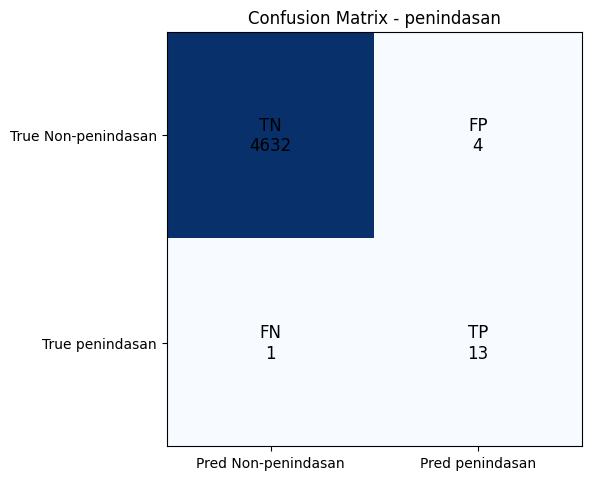

Epoch: 5


/tmp/ipykernel_4187/117330477.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4187/117330477.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8387096774193549

Classification Report:
                precision    recall  f1-score   support

Non-penindasan       1.00      1.00      1.00      4636
    penindasan       0.76      0.93      0.84        14

      accuracy                           1.00      4650
     macro avg       0.88      0.96      0.92      4650
  weighted avg       1.00      1.00      1.00      4650


Train loss: 0.32797938047148295
Validation loss: 0.3384791771366015


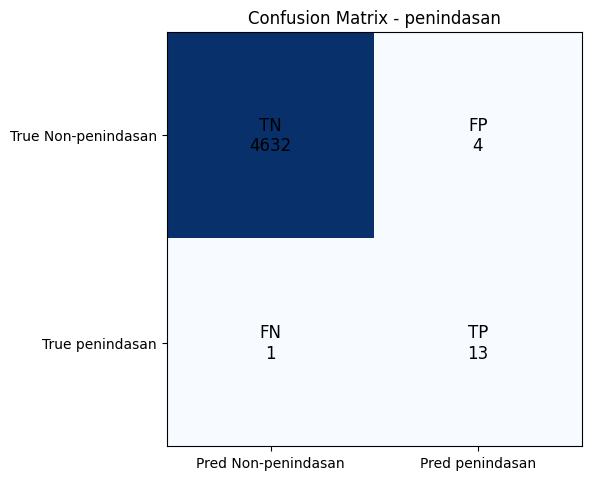

,label,best_f1,best_epoch,export_dir
0,kepedulian,0.983784,5,/content/drive/MyDrive/moralbert_cahya/kepedulian
1,menyakiti,0.912088,3,/content/drive/MyDrive/moralbert_cahya/menyakiti
2,keadilan,0.794521,4,/content/drive/MyDrive/moralbert_cahya/keadilan
3,kecurangan,0.918919,5,/content/drive/MyDrive/moralbert_cahya/kecurangan
4,loyalitas,0.792453,5,/content/drive/MyDrive/moralbert_cahya/loyalitas
5,pengkhianatan,0.987013,1,/content/drive/MyDrive/moralbert_cahya/pengkhi...
6,otoritas,0.946667,5,/content/drive/MyDrive/moralbert_cahya/otoritas
7,pembangkangan,0.923077,2,/content/drive/MyDrive/moralbert_cahya/pembang...
8,kesucian,0.689362,5,/content/drive/MyDrive/moralbert_cahya/kesucian
9,kemerosotan,0.926829,2,/content/drive/MyDrive/moralbert_cahya/kemeros...


In [17]:
from torch.cuda.amp import GradScaler, autocast

scaler = GradScaler()

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

possible_labels = [
    "kepedulian", "menyakiti",
    "keadilan", "kecurangan",
    "loyalitas", "pengkhianatan",
    "otoritas", "pembangkangan",
    "kesucian", "kemerosotan",
    "kebebasan", "penindasan"
]

bert_original_embeddings = None
training_summary = []

for lab_idx, lab in enumerate(possible_labels):

    best_f1 = -1
    best_epoch = -1

    num_labels = 2
    epochs = 5
    batch_size = 16

    rw = 0.1
    iw = 0.01

    print("Models for predicting moral dimension with BERT Base")
    print(f"Label: {lab}")
    print(f"Parameters: reconstruction_weight = {rw}; identity_weight = {iw}")

    temp_bert_model = AutoModel.from_pretrained(base_model).to(
        torch.device("cuda" if torch.cuda.is_available() else "cpu")
    )

    if bert_original_embeddings is None:
        bert_original_embeddings = encode_corpus(
            train_input_ids,
            train_attention_masks,
            temp_bert_model
        )

    train_binary_labels = train_df[lab].astype(int).tolist()
    val_binary_labels = test_df[lab].astype(int).tolist()

    positive_ratio = sum(train_binary_labels) / len(train_binary_labels)
    class_weight = [positive_ratio, 1 - positive_ratio]

    train_set = TensorDataset(
        train_input_ids,
        train_token_type_ids,
        train_attention_masks,
        torch.tensor(train_binary_labels, dtype=torch.long),
        bert_original_embeddings
    )

    val_set = TensorDataset(
        test_input_ids,
        test_token_type_ids,
        test_attention_masks,
        torch.tensor(val_binary_labels, dtype=torch.long)
    )

    train_dataloader = DataLoader(train_set, sampler=RandomSampler(train_set), batch_size=batch_size)
    validation_dataloader = DataLoader(val_set, batch_size=batch_size)

    total_steps = len(train_dataloader) * epochs
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    config = PlainBERTConfig(
        base_model_name_or_path=base_model,
        num_labels=num_labels,
        class_weight=[float(class_weight[0]), float(class_weight[1])],
        reconstruction_weight=rw,
        identity_weight=iw,
        moral_weight=1.0,
        freeze_bert=False,
        id2label={"0": f"Non-{lab}", "1": lab},
        label2id={f"Non-{lab}": 0, lab: 1},
    )

    model = PlainBERTForSequenceClassification(config).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=0,
        num_training_steps=total_steps
    )

    for epoch in trange(epochs, desc=f"Epochs for {lab}"):

        print("Epoch:", epoch + 1)
        model.train()

        tr_loss = 0
        nb_tr_steps = 0

        for step, batch in enumerate(train_dataloader):
            batch = tuple(t.to(device) for t in batch)
            b_input_ids, b_token_type_ids, b_input_mask, b_labels, bert_embeddings = batch

            optimizer.zero_grad()

            with autocast():
                outputs = model(
                    input_ids=b_input_ids,
                    token_type_ids=b_token_type_ids,
                    attention_mask=b_input_mask,
                    labels=b_labels,
                    original_bert_embeddings=bert_embeddings
                )
                loss = outputs.loss

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            tr_loss += loss.item()
            nb_tr_steps += 1

        model.eval()
        val_loss = 0
        nb_val_steps = 0
        y_true = []
        y_pred = []

        for batch in validation_dataloader:
            batch = tuple(t.to(device) for t in batch)
            b_input_ids, b_token_type_ids, b_input_mask, b_labels = batch

            with torch.no_grad():
                with autocast():
                    outputs = model(
                        input_ids=b_input_ids,
                        token_type_ids=b_token_type_ids,
                        attention_mask=b_input_mask,
                        labels=b_labels
                    )

                val_loss += outputs.loss.item()
                logits = outputs.logits.detach().cpu().numpy()
                label_ids = b_labels.detach().cpu().numpy()
                predicted_labels = np.argmax(logits, axis=1)

                y_true.extend(label_ids)
                y_pred.extend(predicted_labels)
                nb_val_steps += 1

        print("Evaluation")
        target_names = [f"Non-{lab}", lab]
        report = classification_report(y_true, y_pred, target_names=target_names, zero_division=0)
        f1 = f1_score(y_true, y_pred, average="binary", zero_division=0)

        print(f"F1 score: {f1}")
        print("\nClassification Report:")
        print(report)
        print(f"\nTrain loss: {tr_loss / max(nb_tr_steps, 1)}")
        print(f"Validation loss: {val_loss / max(nb_val_steps, 1)}")

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        fig, ax = plt.subplots(figsize=(6, 6))

        matrix_display = [
            [tn, fp],
            [fn, tp]
        ]

        im = ax.imshow(matrix_display, cmap="Blues")

        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels([f"Pred Non-{lab}", f"Pred {lab}"])
        ax.set_yticklabels([f"True Non-{lab}", f"True {lab}"])

        ax.set_title(f"Confusion Matrix - {lab}")

        labels_text = [
            [f"TN\n{tn}", f"FP\n{fp}"],
            [f"FN\n{fn}", f"TP\n{tp}"]
        ]

        for i in range(2):
            for j in range(2):
                ax.text(j, i, labels_text[i][j], ha="center", va="center", fontsize=12)

        plt.tight_layout()
        plt.show()

        if f1 > best_f1:
            best_f1 = f1
            best_epoch = epoch + 1
            print("best_F1", best_f1)
            print("Saving best native Hugging Face model ...")

            export_native_plainbert_checkpoint(
                model=model,
                tokenizer=tokenizer,
                export_root=HF_EXPORT_ROOT,
                label_name=lab,
                best_f1=best_f1,
                threshold=0.5
            )

    del temp_bert_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    training_summary.append({
        "label": lab,
        "best_f1": best_f1,
        "best_epoch": best_epoch,
        "export_dir": str(HF_EXPORT_ROOT / lab.replace(" ", "_"))
    })

training_summary = pd.DataFrame(training_summary)
training_summary

# Predictions

In [18]:
test_df = pd.read_csv("test_indonesia.csv")

In [19]:
test_df.shape

(4650, 16)

In [20]:
# pd.merge(test_df, lib_opp, how = 'inner', on = 'text')

In [21]:
base_model = "cahya/bert-base-indonesian-1.5G"
input_files = test_df["sentence"].values

tokenizer = AutoTokenizer.from_pretrained(base_model)

original_input_id = []
original_attention_masks = []
original_token_type_id = []

def preprocessing(input_text, tokenizer):
    return tokenizer(
        input_text,
        add_special_tokens=True,
        max_length=150,
        padding="max_length",
        truncation=True,
        return_attention_mask=True,
        return_token_type_ids=True,
        return_tensors="pt"
    )

for sample in input_files:
    original_encoding_dict = preprocessing(sample, tokenizer)

    original_input_id.append(original_encoding_dict["input_ids"])
    original_attention_masks.append(original_encoding_dict["attention_mask"])

    original_token_type = torch.zeros_like(original_encoding_dict["input_ids"])
    original_token_type[original_encoding_dict["input_ids"] != 0] = 0
    original_token_type_id.append(original_token_type)

original_input_id = torch.cat(original_input_id, dim=0)
original_attention_masks = torch.cat(original_attention_masks, dim=0)
original_token_type_id = torch.cat(original_token_type_id, dim=0)

In [22]:
suffix

'_moral_multilabel_balinese'

In [24]:
import torch

torch.set_default_device("cpu")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [27]:
possible_labels = [
    "kepedulian", "menyakiti",
    "keadilan", "kecurangan",
    "loyalitas", "pengkhianatan",
    "otoritas", "pembangkangan",
    "kesucian", "kemerosotan",
    "kebebasan", "penindasan"
]

import torch
torch.set_default_device("cpu")  # cegah meta device context tetap aktif

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

predictions = []
threshold_summary = []

for lab_idx, lab in enumerate(possible_labels):
    print(f"\nProcessing label: {lab}")

    best_f1 = 0
    best_th = 0.5
    best_y = None

    true_labels_for_lab = test_df[lab].astype(int).tolist()

    val_set = TensorDataset(
        original_input_id,
        original_token_type_id,
        original_attention_masks,
        torch.tensor(true_labels_for_lab, dtype=torch.long)
    )

    validation_dataloader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

    checkpoint_folder = HF_EXPORT_ROOT / lab.replace(" ", "_")

    model = PlainBERTForSequenceClassification.from_pretrained(str(checkpoint_folder))
    model = model.to(device)
    model.eval()

    all_probs = []
    y_true = []

    for batch in validation_dataloader:
        batch = tuple(t.to(device) for t in batch)
        b_input_ids, b_token_type_ids, b_input_mask, b_labels = batch

        with torch.no_grad():
            outputs = model(
                input_ids=b_input_ids,
                token_type_ids=b_token_type_ids,
                attention_mask=b_input_mask
            )

            logits = outputs.logits.detach().cpu()
            probs = torch.softmax(logits, dim=1).numpy()[:, 1]

            all_probs.extend(probs.tolist())
            y_true.extend(b_labels.detach().cpu().numpy().tolist())

    all_probs = np.array(all_probs)
    y_true = np.array(y_true)

    for th in np.arange(0.05, 1.00, 0.05):
        y_pred = (all_probs >= th).astype(int)
        f1 = f1_score(y_true, y_pred, average="binary", zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_th = th
            best_y = y_pred.copy()

    threshold_summary.append({
        "label": lab,
        "best_threshold": float(best_th),
        "best_f1": float(best_f1)
    })

    if lab_idx == 0:
        for ex_id, (pred_label, true_label) in enumerate(zip(best_y, y_true)):
            predictions.append({
                "id": ex_id,
                f"pred_{lab}": int(pred_label),
                f"true_{lab}": int(true_label)
            })
    else:
        for ex_id, (pred_label, true_label) in enumerate(zip(best_y, y_true)):
            predictions[ex_id][f"pred_{lab}"] = int(pred_label)
            predictions[ex_id][f"true_{lab}"] = int(true_label)

    print("Evaluation")
    print(f"{lab} | best threshold: {best_th:.2f} | best F1: {best_f1:.4f}")

    target_names = [f"Non-{lab}", lab]
    report = classification_report(
        y_true,
        best_y,
        target_names=target_names,
        zero_division=0
    )

    print("\nClassification Report:")
    print(report)

pred_df = pd.DataFrame(predictions)
threshold_df = pd.DataFrame(threshold_summary)


Processing label: kepedulian


RuntimeError: You are using `from_pretrained` with a meta device context manager or `torch.set_default_device('meta')`.
This is an anti-pattern as `from_pretrained` wants to load existing weights.
If you want to initialize an empty model on the meta device, use the context manager or global device with `from_config`, or `ModelClass(config)`

In [ ]:
pd.set_option('display.max_columns', None)


In [ ]:
results = []

for idx_lab, lab in enumerate(possible_labels):
    result = {"Moral Value": lab}
    true = test_df[lab].values
    candidate = pred_df["pred_" + lab].values

    result["F1 Score (Binary)"] = f1_score(true, candidate, average="binary", zero_division=0)
    result["F1 Score (Weighted)"] = f1_score(true, candidate, average="weighted", zero_division=0)

    result["Precision Score (Binary)"] = precision_score(true, candidate, average="binary", zero_division=0)
    result["Precision Score (Weighted)"] = precision_score(true, candidate, average="weighted", zero_division=0)

    result["Recall Score (Binary)"] = recall_score(true, candidate, average="binary", zero_division=0)
    result["Recall Score (Weighted)"] = recall_score(true, candidate, average="weighted", zero_division=0)

    result["Accuracy"] = accuracy_score(true, candidate)

    results.append(result)

results = pd.DataFrame(results)

In [ ]:
results

### Bootstraping:

In [ ]:
possible_labels = [
    "kepedulian", "menyakiti",
    "keadilan", "kecurangan",
    "loyalitas", "pengkhianatan",
    "otoritas", "pembangkangan",
    "kesucian", "kemerosotan",
    "kebebasan", "penindasan"
]

test_df.reset_index(drop=True, inplace=True)
n_bootstrap_iters = 1000

bootstrap_results = {
    label: {
        metric: [] for metric in [
            "F1 (Binary)", "F1 (Macro)", "F1 (Weighted)",
            "Precision (Binary)", "Precision (Macro)", "Precision (Weighted)",
            "Recall (Binary)", "Recall (Macro)", "Recall (Weighted)",
            "Accuracy"
        ]
    } for label in possible_labels
}

for _ in range(n_bootstrap_iters):
    for lab in possible_labels:
        sample_indices = resample(np.arange(len(test_df)), replace=True)
        true = test_df.loc[sample_indices, lab].values
        candidate = pred_df.loc[sample_indices, f"pred_{lab}"].values

        bootstrap_results[lab]["F1 (Binary)"].append(f1_score(true, candidate, average="binary", zero_division=0))
        bootstrap_results[lab]["F1 (Macro)"].append(f1_score(true, candidate, average="macro", zero_division=0))
        bootstrap_results[lab]["F1 (Weighted)"].append(f1_score(true, candidate, average="weighted", zero_division=0))
        bootstrap_results[lab]["Precision (Binary)"].append(precision_score(true, candidate, average="binary", zero_division=0))
        bootstrap_results[lab]["Precision (Macro)"].append(precision_score(true, candidate, average="macro", zero_division=0))
        bootstrap_results[lab]["Precision (Weighted)"].append(precision_score(true, candidate, average="weighted", zero_division=0))
        bootstrap_results[lab]["Recall (Binary)"].append(recall_score(true, candidate, average="binary", zero_division=0))
        bootstrap_results[lab]["Recall (Macro)"].append(recall_score(true, candidate, average="macro", zero_division=0))
        bootstrap_results[lab]["Recall (Weighted)"].append(recall_score(true, candidate, average="weighted", zero_division=0))
        bootstrap_results[lab]["Accuracy"].append(accuracy_score(true, candidate))

std_devs = {
    label: {metric: np.std(values) for metric, values in metrics.items()}
    for label, metrics in bootstrap_results.items()
}

final_results = []
for lab in possible_labels:
    result = {"Moral Value": lab}
    true = test_df[lab].values
    candidate = pred_df[f"pred_{lab}"].values

    result["F1 Score (Binary)"] = f"{f1_score(true, candidate, average='binary', zero_division=0):.2f} ± {std_devs[lab]['F1 (Binary)']:.2f}"
    result["F1 Score (Macro)"] = f"{f1_score(true, candidate, average='macro', zero_division=0):.2f} ± {std_devs[lab]['F1 (Macro)']:.2f}"
    result["F1 Score (Weighted)"] = f"{f1_score(true, candidate, average='weighted', zero_division=0):.2f} ± {std_devs[lab]['F1 (Weighted)']:.2f}"

    result["Precision Score (Binary)"] = f"{precision_score(true, candidate, average='binary', zero_division=0):.2f} ± {std_devs[lab]['Precision (Binary)']:.2f}"
    result["Precision Score (Macro)"] = f"{precision_score(true, candidate, average='macro', zero_division=0):.2f} ± {std_devs[lab]['Precision (Macro)']:.2f}"
    result["Precision Score (Weighted)"] = f"{precision_score(true, candidate, average='weighted', zero_division=0):.2f} ± {std_devs[lab]['Precision (Weighted)']:.2f}"

    result["Recall Score (Binary)"] = f"{recall_score(true, candidate, average='binary', zero_division=0):.2f} ± {std_devs[lab]['Recall (Binary)']:.2f}"
    result["Recall Score (Macro)"] = f"{recall_score(true, candidate, average='macro', zero_division=0):.2f} ± {std_devs[lab]['Recall (Macro)']:.2f}"
    result["Recall Score (Weighted)"] = f"{recall_score(true, candidate, average='weighted', zero_division=0):.2f} ± {std_devs[lab]['Recall (Weighted)']:.2f}"

    result["Accuracy"] = f"{accuracy_score(true, candidate):.2f} ± {std_devs[lab]['Accuracy']:.2f}"

    final_results.append(result)

results_df = pd.DataFrame(final_results)
results_df

In [ ]:
results_df